# 04 — MobileNetV2 Fine-Tuning

**Project:** IT22638168 — MaternaLink FER track
**Pipeline position:** step 4 of 8 · see `../README.md`

## Purpose

- Unfreeze the top blocks of the backbone.
- Fine-tune with a reduced learning rate.
- Compare against the frozen-backbone result from notebook 03.
- Watch for overfitting; record the stopping criterion.
- Save the fine-tuned model and run metadata.

## Before running

Read `../../../docs/system/MOOD_STATE_SPEC.md` — it defines the label space this model targets.

> **Note:** Report the delta against notebook 03. If fine-tuning does not help, that is a finding.

## Status

Not yet run.

> **Scope of this notebook.** This notebook **unfreezes part of the ImageNet-pretrained
> MobileNetV2 backbone** and fine-tunes it end-to-end on the 7 FER-2013 classes, then asks one
> question: **does fine-tuning beat notebook 03's frozen-backbone baseline by more than seed
> noise?** Four factors are decided by measurement on the validation split — **augmentation**
> (off/on), **unfreeze depth** (shallow/deep), **BatchNorm mode** (frozen/trainable) and **class
> weighting** (unweighted/balanced) — followed by a three-seed repeat of the winner.
>
> It does **not** load, read, index or evaluate anything from the **TEST / PrivateTest** split
> (notebook 05 touches it exactly once), does **not** resample/oversample/undersample — class
> weighting is the compared alternative and resampling is prohibited — does **not** encode any
> 7→3 mood mapping, does **not** choose `τ_face_min` or `N_smooth`, does **not** apply any
> confidence cut-off or temporal smoothing, and does **not** quantize. It writes raw, unthresholded
> validation probabilities so those later decisions can be made from evidence rather than guessed
> here.
>
> **Inherited from notebook 03 and not re-decided here:** input **96×96×3**, grayscale
> replicated to 3 channels, `mobilenet_v2.preprocess_input`, MobileNetV2 `alpha=1.0` with ImageNet
> weights, a 7-class softmax head, and seed 42 as the default.
>
> **No plot in this notebook contains a face.** Curves and bar charts only.

## Environment setup — WSL2 Ubuntu with GPU

This notebook is written for the **WSL2** conda environment `maternalink-fer-gpu`
(kernel *WSL GPU (MaternaLink FER)*), which has a working CUDA TensorFlow build. Fine-tuning a
backbone is not a CPU-affordable operation, unlike notebook 03's cached-embedding head training.

Two paths matter and they are deliberately different:

- **Images are read from `~/fer/data/raw`**, i.e. the WSL *native* ext4 filesystem. Reading the same
  800 JPEGs from the Windows mount `/mnt/c` was measured at **17.0 s vs 2.7 s** — a 6.4×
  penalty imposed by the 9p/drvfs translation layer, paid on every file. The dataset is copied into
  WSL once so that penalty is never paid per epoch. The `/mnt/c` copy is kept only as a **fallback**,
  and taking it prints a loud warning.
- **Artifacts are written straight into the repo** under
  `/mnt/c/.../IT22638168/ml/fer/{outputs,plots,models}`. These are a few dozen files totalling a few
  MB, written once at the end, so the mount penalty is irrelevant — and writing them in place
  means there is no zip step, no download step, and no manual copy-back.

`REPO_ROOT` is auto-detected by walking up from the working directory until a directory containing
`ml/fer/notebooks` is found, so the notebook is correct regardless of where Jupyter was started.

In [1]:
import os
import sys
import time

# --- repo root: walk up until ml/fer/notebooks is found ----------------------
def find_repo_root(start=None, max_up=8):
    """Auto-detect the repository root; never depends on the CWD being the notebook dir."""
    cur = os.path.abspath(start or os.getcwd())
    tried = []
    for _ in range(max_up):
        tried.append(cur)
        if os.path.isdir(os.path.join(cur, "ml", "fer", "notebooks")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise FileNotFoundError(
        "Could not locate the repository root (a directory containing ml/fer/notebooks). "
        f"Directories tried, walking up from the CWD: {tried}"
    )

REPO_ROOT = find_repo_root()
FER_ROOT = os.path.join(REPO_ROOT, "ml", "fer")
print("REPO_ROOT:", REPO_ROOT)
print("FER_ROOT: ", FER_ROOT)
print("CWD:      ", os.getcwd())
print("Platform: ", sys.platform, "|", os.uname().release if hasattr(os, "uname") else "n/a")


# --- DATA_ROOT: prefer the WSL-native copy, fall back to the repo copy --------
def find_data_root(search_root, max_depth=3):
    """Return the directory that directly contains both 'train' and 'test'."""
    if not os.path.isdir(search_root):
        raise FileNotFoundError(f"search root does not exist: {search_root}")
    queue = [(search_root, 0)]
    visited = []
    while queue:
        current, depth = queue.pop(0)
        try:
            entries = os.listdir(current)
        except OSError:
            continue
        visited.append(current)
        lower = {e.lower(): e for e in entries}
        if "train" in lower and "test" in lower:
            tr = os.path.join(current, lower["train"])
            te = os.path.join(current, lower["test"])
            if os.path.isdir(tr) and os.path.isdir(te):
                return current
        if depth < max_depth:
            for e in entries:
                sub = os.path.join(current, e)
                if os.path.isdir(sub):
                    queue.append((sub, depth + 1))
    raise FileNotFoundError(
        f"no directory containing both 'train' and 'test' within {max_depth} levels of "
        f"{search_root}. Examined: {visited}"
    )

DATA_ROOT_CANDIDATES = [
    ("wsl-native", os.path.expanduser("~/fer/data/raw")),
    ("repo-mnt-c", os.path.join(FER_ROOT, "data", "raw")),
]

DATA_ROOT = None
DATA_ROOT_SOURCE = None
print()
print("Resolving DATA_ROOT (preference order: WSL-native, then the repo copy on /mnt/c):")
for _label, _cand in DATA_ROOT_CANDIDATES:
    print(f"  [{_label}] {_cand} -> exists={os.path.isdir(_cand)}")
    if DATA_ROOT is None and os.path.isdir(_cand):
        try:
            DATA_ROOT = find_data_root(_cand)
            DATA_ROOT_SOURCE = _label
        except FileNotFoundError as _e:
            print(f"      rejected: {_e}")

if DATA_ROOT is None:
    raise FileNotFoundError(
        "Neither candidate data root is usable. Copy the FER-2013 raw tree into the WSL native "
        "filesystem first:  mkdir -p ~/fer/data && cp -r "
        f"{os.path.join(FER_ROOT, 'data', 'raw')} ~/fer/data/"
    )

print()
print("Resolved DATA_ROOT:", DATA_ROOT, f"(source: {DATA_ROOT_SOURCE})")

SLOW_MOUNT = DATA_ROOT.startswith("/mnt/")
if SLOW_MOUNT:
    print()
    print("!" * 78)
    print("!!  WARNING - reading images from the WINDOWS MOUNT (/mnt/c).                !!")
    print("!!                                                                          !!")
    print("!!  Measured on this machine: 800 JPEGs took 17.0 s from /mnt/c versus       !!")
    print("!!  2.7 s from the WSL-native filesystem - a 6.4x penalty per file, paid     !!")
    print("!!  through the 9p/drvfs translation layer.                                  !!")
    print("!!                                                                          !!")
    print("!!  Section 2 decodes every image ONCE into RAM, so this costs a single      !!")
    print("!!  slow pass rather than a slow pass per epoch - but it is still several    !!")
    print("!!  minutes that need not be spent. Fix it with:                             !!")
    print("!!      mkdir -p ~/fer/data && cp -r <repo>/ml/fer/data/raw ~/fer/data/      !!")
    print("!" * 78)
else:
    print("Reading images from the WSL-native filesystem - no /mnt/c I/O penalty.")

# --- artifact directories: straight into the repo, no zip/download step ------
OUT_DIR    = os.path.join(FER_ROOT, "outputs")
PLOT_DIR   = os.path.join(FER_ROOT, "plots")
MODELS_DIR = os.path.join(FER_ROOT, "models")
for _d in (OUT_DIR, PLOT_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)
print()
print("OUT_DIR:   ", OUT_DIR)
print("PLOT_DIR:  ", PLOT_DIR)
print("MODELS_DIR:", MODELS_DIR)

# --- byte-budget tracker (same discipline as notebooks 02 and 03) ------------
# Only ~3.4 GB free on the Windows disk, so every file this notebook writes is
# recorded and totalled at the end. This notebook writes NO regenerable cache -
# the in-RAM image array of section 2 never touches disk - so there is one bucket.
_WRITTEN_FILES = []

def track_write(path, bucket="artifact"):
    """Record a file this notebook wrote, for the end-of-notebook byte report."""
    size = os.path.getsize(path)
    _WRITTEN_FILES.append((path, size))
    return size

def bucket_bytes(files):
    return int(sum(sz for _, sz in files))


REPO_ROOT: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168
FER_ROOT:  /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer
CWD:       /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/notebooks
Platform:  linux | 6.6.87.2-microsoft-standard-WSL2

Resolving DATA_ROOT (preference order: WSL-native, then the repo copy on /mnt/c):
  [wsl-native] /home/yasinduslpredetor/fer/data/raw -> exists=True
  [repo-mnt-c] /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/data/raw -> exists=True

Resolved DATA_ROOT: /home/yasinduslpredetor/fer/data/raw (source: wsl-native)
Reading images from the WSL-native filesystem - no /mnt/c I/O penalty.

OUT_DIR:    /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs
PLOT_DIR:   /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/plots
MODELS_DIR: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/models


## 1. GPU gate — fail loudly, early

Fine-tuning is not optional-GPU work. A frozen backbone lets notebook 03 cache embeddings and train
a 1280→7 head in seconds on a CPU; **once the backbone is unfrozen every epoch is 26,901 full
forward *and* backward passes through MobileNetV2**, which is hours per epoch on a CPU and would put
a 7-run experiment beyond any usable timescale. So this cell checks for a GPU and **raises** if
there is none, rather than starting a run nobody can finish.

Two GPU-specific settings are applied, both only when a GPU is actually present:

- **`mixed_float16`.** The RTX 3050's tensor cores execute float16 matrix maths substantially faster
  than float32, and activations at half precision roughly halve the memory those activations
  occupy — which is what makes batch 64 at 96×96 fit in **6 GB**. The **final Dense layer is
  forced back to `dtype="float32"`**: a softmax over 7 logits in float16 can overflow or lose
  resolution in the exponentials, and the loss is computed from those probabilities, so that one
  layer stays in full precision. This is the standard Keras mixed-precision recipe, not a
  workaround.
- **`set_memory_growth(gpu, True)`** on every visible GPU. By default TensorFlow reserves nearly all
  of VRAM at the first allocation; with only 6 GB and a display attached, that turns a recoverable
  fit into a hard allocator failure. Growth mode allocates as needed instead.

In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__, "| Keras:", tf.keras.__version__)

GPUS = tf.config.list_physical_devices("GPU")
print("tf.config.list_physical_devices('GPU'):", GPUS)

if not GPUS:
    print()
    print("!" * 78)
    print("!!                            NO GPU VISIBLE                                !!")
    print("!!                                                                          !!")
    print("!!  This notebook FINE-TUNES the MobileNetV2 backbone. Unlike notebook 03,  !!")
    print("!!  which trained a 1280->7 head on cached embeddings, every epoch here is  !!")
    print("!!  a full forward AND backward pass through the backbone for all ~26,901   !!")
    print("!!  training images. On a CPU that is HOURS PER EPOCH, and this notebook    !!")
    print("!!  runs SEVEN trainings of up to 40 epochs each.                           !!")
    print("!!                                                                          !!")
    print("!!  Start Jupyter from the WSL2 conda env 'maternalink-fer-gpu' and select  !!")
    print("!!  the kernel 'WSL GPU (MaternaLink FER)'. Verify from a WSL shell with:   !!")
    print("!!      conda activate maternalink-fer-gpu                                  !!")
    print("!!      python -c 'import tensorflow as tf; print(tf.config.list_physical_devices())'")
    print("!" * 78)
    raise RuntimeError(
        "No GPU visible to TensorFlow. Fine-tuning the backbone on CPU takes hours per epoch; "
        "refusing to start. Use the WSL2 GPU kernel 'WSL GPU (MaternaLink FER)'."
    )

# --- memory growth: 6 GB card, do not pre-reserve the whole device -----------
for _gpu in GPUS:
    try:
        tf.config.experimental.set_memory_growth(_gpu, True)
        print(f"  set_memory_growth(True) on {_gpu.name}")
    except RuntimeError as _e:
        # Raised if the device was already initialised earlier in this kernel session.
        print(f"  could not set memory growth on {_gpu.name}: {_e}")

# --- device identity, recorded in the run metadata ---------------------------
GPU_DEVICE_NAME = GPUS[0].name
try:
    _details = tf.config.experimental.get_device_details(GPUS[0])
    GPU_DEVICE_DESCRIPTION = _details.get("device_name", "unknown")
    GPU_COMPUTE_CAPABILITY = _details.get("compute_capability", None)
except Exception:
    GPU_DEVICE_DESCRIPTION = "unknown"
    GPU_COMPUTE_CAPABILITY = None

print()
print("GPU device name:      ", GPU_DEVICE_NAME)
print("GPU device description:", GPU_DEVICE_DESCRIPTION)
print("Compute capability:   ", GPU_COMPUTE_CAPABILITY)
print("Logical GPUs:         ", tf.config.list_logical_devices("GPU"))

# --- mixed precision, GPU only ----------------------------------------------
tf.keras.mixed_precision.set_global_policy("mixed_float16")
MIXED_PRECISION = True
_policy = tf.keras.mixed_precision.global_policy()
print()
print("Mixed-precision policy:", _policy.name)
print("  compute dtype:", _policy.compute_dtype, "| variable dtype:", _policy.variable_dtype)
print("  the FINAL Dense/softmax layer is forced to dtype='float32' in section 4 for")
print("  numerical stability of the softmax and the loss.")

# --- a real matmul on the device, so 'GPU present' means 'GPU works' ---------
with tf.device("/GPU:0"):
    _a = tf.random.normal((512, 512))
    _b = tf.matmul(_a, _a)
    _ = float(tf.reduce_sum(_b).numpy())
print()
print("[PASS] executed a 512x512 matmul on /GPU:0 - the device is usable, not merely listed.")
GPU_AVAILABLE = True


I0000 00:00:1787482822.538615    4566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787482822.601661    4566 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787482825.927998    4566 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | Keras: 3.15.1
tf.config.list_physical_devices('GPU'): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
  set_memory_growth(True) on /physical_device:GPU:0

GPU device name:       /physical_device:GPU:0
GPU device description: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Compute capability:    (8, 6)


I0000 00:00:1787482830.290034    4566 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3617 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Logical GPUs:          [LogicalDevice(name='/device:GPU:0', device_type='GPU')]

Mixed-precision policy: mixed_float16
  compute dtype: float16 | variable dtype: float32
  the FINAL Dense/softmax layer is forced to dtype='float32' in section 4 for
  numerical stability of the softmax and the loss.

[PASS] executed a 512x512 matmul on /GPU:0 - the device is usable, not merely listed.


## Run metadata (§0 — stub repair)

Every training/evaluation notebook records its own run (Gate 1A resolution: no separate
experiment-tracking infrastructure, the notebook is responsible for itself — satisfies NFR-12).
This cell runs **after** environment setup and the GPU gate so it can capture the resolved
`DATA_ROOT`, the GPU device, and the dataset hash.

> **Repair note (§0).** The stub version of this cell carried unescaped templating braces —
> `"hyperparameters": {{}}`, `"metrics": {{}}`, and a stray `}}` closing both the dict and the
> function — which is a `SyntaxError` as written. Repaired to plain `{}` here, exactly the same
> fix already applied to notebooks 01, 02 and 03. `save_run` also gains `outdir=None` defaulting to
> the resolved `OUT_DIR` rather than a hard-coded `"../outputs"`.

`dataset_version` is the manifest filename plus its **SHA-256, computed at runtime**; `environment`
is `"wsl2-gpu"`; `model_version` is filled in by §6 when the fine-tuned model is written.

In [3]:
"""Run metadata — every training/evaluation notebook records its own run.

This is the project's experiment tracking (Gate 1A resolution): no separate
infrastructure, the notebook is responsible. Satisfies NFR-12.
"""
import json, os, time, random, sys, hashlib, importlib.metadata
import numpy as np

def _pkg_version(name, module=None, alt_dist_names=None):
    """Best-effort package version lookup; never raises."""
    for dist_name in [name] + list(alt_dist_names or []):
        try:
            return importlib.metadata.version(dist_name)
        except Exception:
            continue
    try:
        mod = module or __import__(name)
        return getattr(mod, "__version__", "unknown")
    except Exception:
        return "unknown"

PACKAGE_VERSIONS = {
    "python":       sys.version.split()[0],
    "numpy":        _pkg_version("numpy"),
    "pandas":       _pkg_version("pandas"),
    "Pillow":       _pkg_version("Pillow", module=__import__("PIL")),
    "matplotlib":   _pkg_version("matplotlib"),
    "scikit-learn": _pkg_version("scikit-learn", module=__import__("sklearn")),
    "tensorflow":   _pkg_version(
        "tensorflow", module=tf,
        alt_dist_names=["tensorflow-cpu", "tensorflow-gpu", "tensorflow-intel"],
    ),
    "keras":        _pkg_version("keras", module=tf.keras),
}
print("Package versions:")
for _k, _v in PACKAGE_VERSIONS.items():
    print(f"  {_k:<13} {_v}")

# --- dataset_version: manifest filename + SHA-256 computed at runtime --------
MANIFEST_PATH = os.path.join(OUT_DIR, "splits_cleaned.csv")
if not os.path.isfile(MANIFEST_PATH):
    raise FileNotFoundError(
        f"Manifest not found: {MANIFEST_PATH}. Run notebook 02 first (it writes splits_cleaned.csv)."
    )

def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

MANIFEST_SHA256 = sha256_file(MANIFEST_PATH)
DATASET_VERSION = f"{os.path.basename(MANIFEST_PATH)}@sha256:{MANIFEST_SHA256}"
print()
print("Manifest:        ", MANIFEST_PATH)
print("Manifest SHA-256:", MANIFEST_SHA256)

RUN = {
    "run_id":           time.strftime("run_%Y%m%d_%H%M%S"),
    "timestamp":        time.strftime("%Y-%m-%d %H:%M:%S"),
    "notebook":         "04_mobilenetv2_fine_tuning",
    "dataset":          "FER-2013",
    "dataset_path":     DATA_ROOT,
    "dataset_root_source": DATA_ROOT_SOURCE,
    "dataset_version":  DATASET_VERSION,
    "model_version":    None,      # set in section 6 when the fine-tuned model is saved
    "environment":      "wsl2-gpu",
    "gpu_device":       GPU_DEVICE_NAME,
    "gpu_description":  GPU_DEVICE_DESCRIPTION,
    "mixed_precision":  bool(MIXED_PRECISION),
    "package_versions": PACKAGE_VERSIONS,
    "hyperparameters":  {},        # populated in section 4 from the actual staged design
    "random_seed":      42,
    "metrics":          {},        # populated in sections 5-8 from measured values only
    "notes":            "",
}

# --- seeding: python, numpy, and the full Keras/TF stack ---------------------
random.seed(RUN["random_seed"])
np.random.seed(RUN["random_seed"])
tf.keras.utils.set_random_seed(RUN["random_seed"])

print()
print(json.dumps(RUN, indent=2))

def save_run(run=RUN, outdir=None):
    """Write the run record. Safe to call repeatedly; the last call wins."""
    if outdir is None:
        outdir = OUT_DIR
    os.makedirs(outdir, exist_ok=True)
    path = os.path.join(outdir, run["run_id"] + ".json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(run, f, indent=2)
    print("saved:", path)
    return path

RUN["run_id"]


Package versions:
  python        3.11.15
  numpy         2.4.6
  pandas        3.0.5
  Pillow        12.3.0
  matplotlib    3.11.1
  scikit-learn  1.9.0
  tensorflow    2.21.0
  keras         3.15.1

Manifest:         /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/splits_cleaned.csv
Manifest SHA-256: a75d460f35d14c14cba6830923e5e5483f6d5611e779a9252d0b57fd49325496

{
  "run_id": "run_20260823_163030",
  "timestamp": "2026-08-23 16:30:30",
  "notebook": "04_mobilenetv2_fine_tuning",
  "dataset": "FER-2013",
  "dataset_path": "/home/yasinduslpredetor/fer/data/raw",
  "dataset_root_source": "wsl-native",
  "dataset_version": "splits_cleaned.csv@sha256:a75d460f35d14c14cba6830923e5e5483f6d5611e779a9252d0b57fd49325496",
  "model_version": null,
  "environment": "wsl2-gpu",
  "gpu_device": "/physical_device:GPU:0",
  "gpu_description": "NVIDIA GeForce RTX 3050 6GB Laptop GPU",
  "mixed_precision": true,
  "package_versions": {
    "python": "3.11.15",
    "numpy": "2.4.

'run_20260823_163030'

---

## Work starts here

## 2. Manifest — the same portability fix and the same TEST drop as notebook 03

`splits_cleaned.csv` (written by notebook 02) stores `file_path` values that look like

```
../data/raw\train\angry\Training_10118481.jpg
```

relative, and **Windows backslash-separated**. Consuming them raw would break instantly under WSL.
So the column is **not** consumed as-is: every path is rebuilt from its components against the
`DATA_ROOT` resolved above,

```
os.path.join(DATA_ROOT, split_dir, class, basename)
```

where `split_dir` is `"train"` for `split_group == "TRAIN"` and `"test"` otherwise. Only the
*basename* survives from the original string. This is verbatim the notebook 03 logic — the same
manifest must produce the same rows in both notebooks or the baseline comparison in §5 is
meaningless.

### The TEST split is dropped here and never re-enters

`split_group == "TEST"` rows (the `PrivateTest_` prefix) are filtered out **immediately** after the
manifest is read, before any array, path list or label vector is built, and the only object still
holding them is deleted. The held-out test set is touched exactly once in the whole project, in
notebook 05. `assert_no_test(...)` is re-called at **every** subsequent stage — before loading
pixels into RAM, before every training run, before the probability export, and again in the §8
gates.

The two split-size checks are **assertion targets only**: they are compared against values computed
from the file, PASS/FAIL is printed, and the *measured* counts are what every downstream cell
uses.

In [4]:
import pandas as pd

# --- read the manifest -------------------------------------------------------
manifest_raw = pd.read_csv(MANIFEST_PATH)
print(f"Manifest rows read: {len(manifest_raw)}")
print("Columns:", list(manifest_raw.columns))
print()
print("split_group counts BEFORE dropping TEST:")
print(manifest_raw["split_group"].value_counts().to_string())

# --- PORTABILITY FIX: rebuild every path from its components -----------------
def rebuild_path(file_path, split_group, cls):
    split_dir = "train" if split_group == "TRAIN" else "test"
    basename = os.path.basename(str(file_path).replace("\\", "/"))
    return os.path.join(DATA_ROOT, split_dir, str(cls), basename)

manifest_raw["basename"] = [
    os.path.basename(str(p).replace("\\", "/")) for p in manifest_raw["file_path"]
]
manifest_raw["abs_path"] = [
    rebuild_path(p, g, c)
    for p, g, c in zip(manifest_raw["file_path"], manifest_raw["split_group"], manifest_raw["class"])
]
print()
print("Path rebuild example:")
print("  raw     :", manifest_raw["file_path"].iloc[0])
print("  rebuilt :", manifest_raw["abs_path"].iloc[0])

# --- DROP TEST IMMEDIATELY ---------------------------------------------------
n_before = len(manifest_raw)
n_test_rows = int((manifest_raw["split_group"] == "TEST").sum())
manifest = manifest_raw[manifest_raw["split_group"] != "TEST"].reset_index(drop=True).copy()
n_after = len(manifest)
print()
print("=" * 70)
print("TEST / PrivateTest SPLIT DROPPED")
print("=" * 70)
print(f"  rows before drop:  {n_before}")
print(f"  TEST rows removed: {n_test_rows}")
print(f"  rows after drop:   {n_after}")
print("  The held-out test set is touched exactly once, in notebook 05. Not here.")

del manifest_raw  # the only object in memory that still held TEST rows

assert "TEST" not in set(manifest["split_group"]), "TEST rows survived the filter"
assert not manifest["basename"].str.startswith("PrivateTest_").any(), \
    "a PrivateTest_ file survived the split_group filter"

# --- split frames ------------------------------------------------------------
train_df = manifest[manifest["split_group"] == "TRAIN"].reset_index(drop=True)
val_df   = manifest[manifest["split_group"] == "VAL"].reset_index(drop=True)
n_train_measured = len(train_df)
n_val_measured   = len(val_df)

print()
print("split_group counts AFTER dropping TEST:")
print(manifest["split_group"].value_counts().to_string())

# --- assertion targets (compare-and-report; the MEASURED values are used) ----
ASSERT_TARGETS = {"TRAIN": 26901, "VAL": 3589}
print()
print("=" * 70)
print("SPLIT-SIZE ASSERTIONS (targets inherited from notebook 02's cleaning policy)")
print("=" * 70)
split_gate = {}
for name, target in ASSERT_TARGETS.items():
    got = n_train_measured if name == "TRAIN" else n_val_measured
    ok = (got == target)
    split_gate[name] = ok
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}: expected={target} measured={got}")
if not all(split_gate.values()):
    print()
    print("!" * 70)
    print("!!  SPLIT-SIZE ASSERTION FAILED - the manifest is not the one this      !!")
    print("!!  notebook was written against, and the notebook-03 baseline in       !!")
    print("!!  section 5 may not be comparable. Everything below still runs on the !!")
    print("!!  MEASURED counts; re-check notebook 02 before trusting the delta.    !!")
    print("!" * 70)
else:
    print("  Both split sizes match. Downstream cells use the measured counts regardless.")

# --- every rebuilt path must exist on disk -----------------------------------
print()
print("Verifying every rebuilt path exists on disk...")
_t0 = time.time()
missing = [p for p in manifest["abs_path"] if not os.path.isfile(p)]
print(f"  checked {len(manifest)} paths in {time.time() - _t0:.1f}s")
if missing:
    print(f"  [FAIL] {len(missing)} rebuilt paths do NOT exist. First 10:")
    for p in missing[:10]:
        print("    ", p)
    raise FileNotFoundError(
        f"{len(missing)} rebuilt paths are missing from disk - DATA_ROOT is wrong or the raw "
        f"dataset copy is incomplete. DATA_ROOT={DATA_ROOT}"
    )
print("  [PASS] all rebuilt paths exist.")

# --- label space: integer labels from the SORTED class list ------------------
# Identical rule to notebook 03, so label i means the same class in both notebooks.
CLASS_NAMES = sorted(manifest["class"].unique().tolist())
N_CLASSES = len(CLASS_NAMES)
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
print()
print("Class -> integer label mapping (sorted class list, same as notebook 03):")
for c in CLASS_NAMES:
    print(f"  {CLASS_TO_IDX[c]} -> {c}")
assert N_CLASSES == 7, f"expected 7 FER-2013 classes, found {N_CLASSES}: {CLASS_NAMES}"

train_paths = train_df["abs_path"].tolist()
val_paths   = val_df["abs_path"].tolist()
train_basenames = train_df["basename"].tolist()
val_basenames   = val_df["basename"].tolist()

y_train = np.array([CLASS_TO_IDX[c] for c in train_df["class"]], dtype=np.int64)
y_val   = np.array([CLASS_TO_IDX[c] for c in val_df["class"]],   dtype=np.int64)

print()
print(f"train_paths: {len(train_paths)}  y_train: {y_train.shape}")
print(f"val_paths:   {len(val_paths)}    y_val:   {y_val.shape}")
print()
print("Per-class counts (TRAIN / VAL), measured:")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {c:<9} train={int((y_train == i).sum()):>6}  val={int((y_val == i).sum()):>5}")

# --- the standing no-TEST guard, reused at every later stage -----------------
def assert_no_test(*path_lists, label=""):
    """Raise if any path in any list belongs to the held-out TEST/PrivateTest split."""
    bad = []
    for plist in path_lists:
        for p in plist:
            b = os.path.basename(str(p).replace("\\", "/"))
            if b.startswith("PrivateTest_"):
                bad.append(p)
    if bad:
        raise AssertionError(
            f"TEST-SPLIT LEAK{' in ' + label if label else ''}: {len(bad)} PrivateTest_ files "
            f"reached an array. First: {bad[0]}"
        )
    return True

assert_no_test(train_paths, val_paths, label="section 2 path arrays")
print()
print("[PASS] no PrivateTest_ file is present in train_paths or val_paths.")


Manifest rows read: 34079
Columns: ['file_path', 'split_group', 'class', 'prefix']

split_group counts BEFORE dropping TEST:
split_group
TRAIN    26901
TEST      3589
VAL       3589

Path rebuild example:
  raw     : ../data/raw\train\angry\Training_10118481.jpg
  rebuilt : /home/yasinduslpredetor/fer/data/raw/train/angry/Training_10118481.jpg

TEST / PrivateTest SPLIT DROPPED
  rows before drop:  34079
  TEST rows removed: 3589
  rows after drop:   30490
  The held-out test set is touched exactly once, in notebook 05. Not here.

split_group counts AFTER dropping TEST:
split_group
TRAIN    26901
VAL       3589

SPLIT-SIZE ASSERTIONS (targets inherited from notebook 02's cleaning policy)
  [PASS] TRAIN: expected=26901 measured=26901
  [PASS] VAL: expected=3589 measured=3589
  Both split sizes match. Downstream cells use the measured counts regardless.

Verifying every rebuilt path exists on disk...
  checked 30490 paths in 0.1s
  [PASS] all rebuilt paths exist.

Class -> integer label m

## 2b. Decode every image **once** into RAM — the I/O fix

Notebook 03 could cache the backbone's 1280-d embedding because a frozen backbone is a pure
function of its input. Fine-tuning destroys that: the weights change every step, so the embedding
changes every step, and there is nothing to cache. The naive consequence is that every epoch
re-reads and re-decodes ~30,000 JPEGs from disk — and with augmentation in the pipeline the CPU
becomes the bottleneck while a 6 GB GPU sits idle.

The fix is to pay the decode cost **exactly once**. FER-2013 images are 48×48 grayscale, so the
entire TRAIN + VAL set as `uint8` is

```
30,490 x 48 x 48 x 1 byte  ~=  62 MB
```

which fits in RAM many times over. Every image is decoded once into a `(N, 48, 48)` `uint8` array
at its **native resolution**, and from then on `tf.data` streams slices of that array. There is
**zero file I/O after this cell** — which is exactly why the `/mnt/c` penalty above only costs one
pass rather than one pass per epoch.

> **This is an I/O optimisation only.** The pixels are the *same* pixels notebook 03's pipeline
> read; the augmentation is the *same* augmentation specified in notebook 02; the preprocessing is
> the *same* `mobilenet_v2.preprocess_input` on the *same* 96×96 bilinear upsample of the *same*
> 3-channel grayscale replication. Nothing about the modelling changes — only *when* the bytes are
> read.

Decoding runs through a small `tf.data` pipeline with parallel reads rather than a Python loop
(the parallelism is the whole point on a mount this slow), but the result is materialised into one
contiguous numpy array whose **row order matches the manifest row order exactly** — asserted below,
because label alignment depends on it and a silent reorder would be invisible in the metrics.

In [5]:
AUTOTUNE = tf.data.AUTOTUNE
NATIVE_SIZE = 48          # FER-2013 native resolution; NOT a model input size
INPUT_SIZE  = 96          # model input, inherited from notebook 03's decision
DECODE_BATCH = 256


def load_images_to_ram(paths, label=""):
    """Decode every JPEG ONCE into a (N, 48, 48) uint8 array, order preserved.

    Uses tf.data purely for parallel file reads/decodes; the output is a plain
    contiguous numpy array, so no file is ever touched again after this call.
    """
    assert_no_test(paths, label=f"in-RAM decode ({label})")
    n = len(paths)
    out = np.empty((n, NATIVE_SIZE, NATIVE_SIZE), dtype=np.uint8)

    def _decode(path):
        raw = tf.io.read_file(path)
        img = tf.io.decode_jpeg(raw, channels=1, dct_method="INTEGER_ACCURATE")
        # dct_method pinned: TF's default IDCT is platform/version dependent and differs
        # from PIL by up to ~13 grey levels. INTEGER_ACCURATE is bit-exact with PIL, so
        # decoding is reproducible and the row-order assertion below stays strict.                       # (H, W, 1) uint8
        # FER-2013 is natively 48x48; the resize is an identity for conforming files
        # and a guard for any that are not. round() keeps the uint8 round-trip exact.
        img = tf.image.resize(img, (NATIVE_SIZE, NATIVE_SIZE), method="bilinear")
        img = tf.cast(tf.round(img), tf.uint8)
        return tf.squeeze(img, axis=-1)                                # (48, 48) uint8

    # NO .shuffle(): row i of `out` must correspond to row i of `paths`.
    ds = (tf.data.Dataset.from_tensor_slices(tf.constant(paths, dtype=tf.string))
          .map(_decode, num_parallel_calls=AUTOTUNE, deterministic=True)
          .batch(DECODE_BATCH)
          .prefetch(AUTOTUNE))

    print(f"  decoding {n} images ({label}) ...")
    t0 = time.time()
    filled = 0
    next_report = 5000
    for batch in ds:
        arr = batch.numpy()
        out[filled:filled + len(arr)] = arr
        filled += len(arr)
        if filled >= next_report:
            el = time.time() - t0
            print(f"    {filled:>6}/{n} decoded  ({el:6.1f}s, {filled / max(el, 1e-9):7.0f} img/s)")
            next_report += 5000
    elapsed = time.time() - t0
    assert filled == n, f"decoded {filled} images for {n} paths - count mismatch"
    print(f"    {n:>6}/{n} decoded  ({elapsed:6.1f}s, {n / max(elapsed, 1e-9):7.0f} img/s) DONE")
    return out, float(elapsed)


print("=" * 70)
print("DECODING ALL TRAIN + VAL IMAGES INTO RAM (once)")
print("=" * 70)
_t_load = time.time()
X_train_u8, DECODE_SECONDS_TRAIN = load_images_to_ram(train_paths, label="TRAIN")
X_val_u8,   DECODE_SECONDS_VAL   = load_images_to_ram(val_paths,   label="VAL")
DECODE_SECONDS_TOTAL = float(time.time() - _t_load)

print()
print(f"X_train_u8: {X_train_u8.shape} {X_train_u8.dtype}  "
      f"({X_train_u8.nbytes / 1e6:.1f} MB)")
print(f"X_val_u8:   {X_val_u8.shape} {X_val_u8.dtype}  "
      f"({X_val_u8.nbytes / 1e6:.1f} MB)")
print(f"Total RAM for pixels: {(X_train_u8.nbytes + X_val_u8.nbytes) / 1e6:.1f} MB")
print(f"Total decode wall time: {DECODE_SECONDS_TOTAL:.1f}s "
      f"(TRAIN {DECODE_SECONDS_TRAIN:.1f}s + VAL {DECODE_SECONDS_VAL:.1f}s)")
print("No image file is read again after this cell.")

# --- alignment and sanity assertions ----------------------------------------
assert X_train_u8.shape[0] == y_train.shape[0], "TRAIN pixel/label row-count mismatch"
assert X_val_u8.shape[0] == y_val.shape[0],     "VAL pixel/label row-count mismatch"
assert X_train_u8.dtype == np.uint8 and X_val_u8.dtype == np.uint8, "arrays must be uint8"

# Row-order spot check: re-decode a handful of rows straight from disk with PIL
# (a different decoder and a different code path) and require an exact match.
from PIL import Image
_rng_check = np.random.default_rng(RUN["random_seed"])
_check_idx = _rng_check.choice(len(train_paths), size=min(8, len(train_paths)), replace=False)
_mismatch = 0
for _i in _check_idx:
    _ref = np.array(Image.open(train_paths[int(_i)]).convert("L"), dtype=np.uint8)
    if _ref.shape != (NATIVE_SIZE, NATIVE_SIZE) or not np.array_equal(_ref, X_train_u8[int(_i)]):
        _mismatch += 1
print()
print(f"Row-order check on {len(_check_idx)} random TRAIN rows (PIL re-decode): "
      f"{len(_check_idx) - _mismatch} exact matches, {_mismatch} mismatches")
assert _mismatch == 0, (
    "the in-RAM array does not match an independent decode of the same path - row order or "
    "decoding differs, which would silently mis-label every image"
)
print("[PASS] in-RAM array rows are aligned with the manifest rows.")

assert_no_test(train_paths, val_paths, label="post-decode re-assertion")
print("[PASS] no PrivateTest_ file contributed a single pixel to either array.")


DECODING ALL TRAIN + VAL IMAGES INTO RAM (once)
  decoding 26901 images (TRAIN) ...
      5120/26901 decoded  (   0.6s,    9124 img/s)
     10240/26901 decoded  (   1.1s,    9355 img/s)
     15104/26901 decoded  (   1.7s,    8928 img/s)
     20224/26901 decoded  (   2.2s,    9153 img/s)
     25088/26901 decoded  (   2.8s,    9001 img/s)
     26901/26901 decoded  (   3.0s,    9086 img/s) DONE
  decoding 3589 images (VAL) ...
      3589/3589 decoded  (   0.3s,   10434 img/s) DONE

X_train_u8: (26901, 48, 48) uint8  (62.0 MB)
X_val_u8:   (3589, 48, 48) uint8  (8.3 MB)
Total RAM for pixels: 70.2 MB
Total decode wall time: 3.5s (TRAIN 3.0s + VAL 0.3s)
No image file is read again after this cell.

Row-order check on 8 random TRAIN rows (PIL re-decode): 8 exact matches, 0 mismatches
[PASS] in-RAM array rows are aligned with the manifest rows.
[PASS] no PrivateTest_ file contributed a single pixel to either array.


## 3. Augmentation — notebook 02's `AUGMENTATION_CONFIG`, unchanged

Augmentation was *defined* in notebook 02 (§ augmentation preview) and deliberately **not applied**
there — nothing was written to disk. It could not be used in notebook 03 either, because a cached
frozen-backbone embedding is invalidated the moment the pixels change. Notebook 04 is the first
place it can actually be used, so the config is mirrored here **exactly as notebook 02 defined it**:

| transform | setting | why |
|---|---|---|
| horizontal flip | p = 0.5 | faces are approximately left–right symmetric; a mirrored face is still a valid face |
| **vertical flip** | **FORBIDDEN** | an upside-down face is not a realistic sample and would teach a physically impossible orientation |
| rotation | ±10° | small head-tilt variation; large rotations are unrealistic for a front-facing camera |
| zoom | 0.9–1.1 | crop jitter, mimicking face-detector bounding-box noise |
| translation | ±5 % | position jitter, same rationale |
| brightness | ±0.15 | ambient lighting varies |
| contrast | 0.85–1.15 | camera exposure varies |

Notebook 02 implemented these with OpenCV on `uint8` arrays for its preview; here they are Keras
preprocessing layers so the work happens **on the GPU, per batch**, inside the input pipeline. A
`Sequential` block of preprocessing layers is active **only when `training=True`**, so validation is
never augmented — augmenting the selection set would make every measurement in this notebook
uninterpretable.

Two implementation details worth stating: the layers run **after** the 96×96 resize (augmenting at
48×48 and then upsampling would compound two interpolations), and the result is **clipped to
[0, 255]** before `preprocess_input`, mirroring the `np.clip` in notebook 02's OpenCV version —
`RandomContrast` can otherwise push values outside the valid range. The block is rebuilt per run
with that run's seed, so augmentation is reproducible.

In [6]:
AUGMENTATION_CONFIG = {
    "horizontal_flip": {
        "enabled": True, "probability": 0.5,
        "rationale": "faces are approximately left-right symmetric; a horizontally flipped face "
                     "is still a valid, plausible face.",
    },
    "vertical_flip": {
        "enabled": False,
        "rationale": "INAPPROPRIATE for faces - an upside-down face is not a realistic sample and "
                     "would teach the model a physically impossible orientation.",
    },
    "rotation": {
        "enabled": True, "max_degrees": 10,
        "rationale": "small head-tilt variation; large rotations are unrealistic for a "
                     "front-facing camera use case.",
    },
    "zoom_translate": {
        "enabled": True, "zoom_range": [0.9, 1.1], "translate_frac": 0.05,
        "rationale": "small crop/position jitter mimics face-detector bounding-box noise.",
    },
    "brightness_contrast": {
        "enabled": True, "brightness_delta": 0.15, "contrast_range": [0.85, 1.15],
        "rationale": "camera exposure and ambient lighting vary; the model should not overfit to "
                     "a fixed brightness/contrast.",
    },
}
print("AUGMENTATION_CONFIG (mirrored verbatim from notebook 02):")
print(json.dumps(AUGMENTATION_CONFIG, indent=2))

assert AUGMENTATION_CONFIG["vertical_flip"]["enabled"] is False, \
    "vertical flip is forbidden for faces"


def build_augmentation(seed):
    """Keras preprocessing block implementing AUGMENTATION_CONFIG. Train-time only.

    Operates on float32 images in [0, 255] at the MODEL input size, before
    preprocess_input. Horizontal flip only - RandomFlip('horizontal'), never
    'vertical' or 'horizontal_and_vertical'.
    """
    cfg = AUGMENTATION_CONFIG
    max_deg = cfg["rotation"]["max_degrees"]
    zlo, zhi = cfg["zoom_translate"]["zoom_range"]
    tfrac = cfg["zoom_translate"]["translate_frac"]
    bdelta = cfg["brightness_contrast"]["brightness_delta"]
    clo, chi = cfg["brightness_contrast"]["contrast_range"]

    layers = [
        # p=0.5 is inherent to RandomFlip on a single axis.
        tf.keras.layers.RandomFlip("horizontal", seed=seed, name="aug_hflip"),
        # Keras expresses rotation as a fraction of a full turn.
        tf.keras.layers.RandomRotation(
            factor=max_deg / 360.0, fill_mode="reflect", interpolation="bilinear",
            seed=seed + 1, name="aug_rotate",
        ),
        # zoom_range [0.9, 1.1] -> height/width factor +/- 0.1 about 1.0.
        tf.keras.layers.RandomZoom(
            height_factor=(-(zhi - 1.0), 1.0 - zlo), fill_mode="reflect",
            interpolation="bilinear", seed=seed + 2, name="aug_zoom",
        ),
        tf.keras.layers.RandomTranslation(
            height_factor=tfrac, width_factor=tfrac, fill_mode="reflect",
            interpolation="bilinear", seed=seed + 3, name="aug_translate",
        ),
        tf.keras.layers.RandomBrightness(
            factor=bdelta, value_range=(0.0, 255.0), seed=seed + 4, name="aug_brightness",
        ),
        # RandomContrast(f) samples the contrast factor from [1-f, 1+f].
        tf.keras.layers.RandomContrast(
            factor=(chi - clo) / 2.0, seed=seed + 5, name="aug_contrast",
        ),
    ]
    return tf.keras.Sequential(layers, name="augmentation")


_demo_block = build_augmentation(RUN["random_seed"])
print()
print("Augmentation block (train-time only):")
for _l in _demo_block.layers:
    print(f"  {_l.name:<15} {type(_l).__name__}")
print()
print("Vertical flip is absent by construction: RandomFlip is instantiated with 'horizontal'.")
del _demo_block


AUGMENTATION_CONFIG (mirrored verbatim from notebook 02):
{
  "horizontal_flip": {
    "enabled": true,
    "probability": 0.5,
    "rationale": "faces are approximately left-right symmetric; a horizontally flipped face is still a valid, plausible face."
  },
  "vertical_flip": {
    "enabled": false,
    "rationale": "INAPPROPRIATE for faces - an upside-down face is not a realistic sample and would teach the model a physically impossible orientation."
  },
  "rotation": {
    "enabled": true,
    "max_degrees": 10,
    "rationale": "small head-tilt variation; large rotations are unrealistic for a front-facing camera use case."
  },
  "zoom_translate": {
    "enabled": true,
    "zoom_range": [
      0.9,
      1.1
    ],
    "translate_frac": 0.05,
    "rationale": "small crop/position jitter mimics face-detector bounding-box noise."
  },
  "brightness_contrast": {
    "enabled": true,
    "brightness_delta": 0.15,
    "contrast_range": [
      0.85,
      1.15
    ],
    "rationale":

### 3b. `tf.data` pipelines built from the in-memory arrays

Per batch, on the GPU:

```
uint8 (B,48,48) -> float32 -> expand to (B,48,48,1) -> grayscale_to_rgb (B,48,48,3)
                -> tf.image.resize 96x96 bilinear
                -> [TRAIN only] augmentation block -> clip to [0,255]
                -> mobilenet_v2.preprocess_input   -> (B,96,96,3) in [-1,1]
```

Identical in every respect to the transform notebook 03 applied; only the *source* of the bytes
differs (a RAM slice instead of a file read).

**Shuffling.** TRAIN is shuffled with a full-size buffer and a fixed `seed`, reshuffled every epoch
— a partial buffer over a manifest that is ordered by class would hand the optimiser near-single-
class batches. **Validation is never shuffled**, so row *i* of every prediction array lines up with
row *i* of `y_val` and of `val_basenames`; the probability export in §6 depends on that.

**Class weighting is applied as a per-sample weight inside the pipeline** rather than through
`model.fit(class_weight=...)`. It is the same arithmetic — sample *i* contributes
`w[y_i] · loss_i` — but it is explicit, version-independent, and visible in the dataset element
spec. Validation is **never** weighted: the selection metric must describe the real validation
distribution. This is class *weighting*, not resampling; no image is duplicated, dropped or
synthesised, and the training set is bit-identical between the two weighting arms.

In [7]:
from sklearn.utils.class_weight import compute_class_weight

BATCH_SIZE = 64          # sized for 6 GB of VRAM at 96x96 with mixed precision
SHUFFLE_BUFFER = None    # None -> full dataset size (set per call below)

# --- balanced class weights, computed at runtime from y_train ----------------
BALANCED_WEIGHTS = compute_class_weight(
    class_weight="balanced", classes=np.arange(N_CLASSES), y=y_train,
)
CLASS_WEIGHT_DICT = {int(i): float(w) for i, w in enumerate(BALANCED_WEIGHTS)}
print("Balanced class weights (sklearn compute_class_weight, computed from y_train):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i} {c:<9} n_train={int((y_train == i).sum()):>6}  weight={CLASS_WEIGHT_DICT[i]:.4f}")
print()
print("This is class WEIGHTING (a loss-scaling term), not resampling. Resampling is prohibited "
      "by the spec; no image is duplicated, dropped or synthesised.")

_SAMPLE_WEIGHTS_BALANCED = np.array(
    [CLASS_WEIGHT_DICT[int(y)] for y in y_train], dtype=np.float32
)


def make_dataset(images_u8, labels, training, seed=42, augment=False,
                 sample_weights=None, batch_size=BATCH_SIZE):
    """Build a tf.data pipeline from IN-MEMORY uint8 arrays. No file I/O.

    training=True  -> shuffled every epoch (seeded), augmentation optional.
    training=False -> NEVER shuffled, NEVER augmented, NEVER weighted.
    """
    if training and sample_weights is not None:
        ds = tf.data.Dataset.from_tensor_slices(
            (images_u8, labels, sample_weights.astype(np.float32))
        )
    else:
        ds = tf.data.Dataset.from_tensor_slices((images_u8, labels))

    if training:
        ds = ds.shuffle(len(images_u8), seed=seed, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    aug_block = build_augmentation(seed) if (training and augment) else None

    def _prep(x, *rest):
        x = tf.cast(x, tf.float32)
        x = tf.expand_dims(x, axis=-1)                                   # (B,48,48,1)
        x = tf.image.grayscale_to_rgb(x)                                 # (B,48,48,3)
        x = tf.image.resize(x, (INPUT_SIZE, INPUT_SIZE), method="bilinear")
        if aug_block is not None:
            x = aug_block(x, training=True)
            # mirrors notebook 02's np.clip(..., 0, 255) after brightness/contrast
            x = tf.clip_by_value(x, 0.0, 255.0)
        x = tf.keras.applications.mobilenet_v2.preprocess_input(x)       # -> [-1, 1]
        return (x,) + tuple(rest)

    return ds.map(_prep, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)


def make_train_ds(seed, augment, weighting):
    sw = _SAMPLE_WEIGHTS_BALANCED if weighting == "balanced" else None
    return make_dataset(X_train_u8, y_train, training=True, seed=seed,
                        augment=augment, sample_weights=sw)


def make_val_ds():
    # Never shuffled, never augmented, never weighted - selection depends on it.
    return make_dataset(X_val_u8, y_val, training=False)


VAL_DS = make_val_ds()

# --- shape / range verification on one batch of each ---------------------------
_xb, _yb = next(iter(VAL_DS))
print()
print("VAL batch:   x", _xb.shape, _xb.dtype, f"range [{float(tf.reduce_min(_xb)):.3f}, "
      f"{float(tf.reduce_max(_xb)):.3f}]  y", _yb.shape, _yb.dtype)
assert tuple(_xb.shape[1:]) == (INPUT_SIZE, INPUT_SIZE, 3), "unexpected validation batch shape"

_dbg_ds = make_train_ds(seed=RUN["random_seed"], augment=True, weighting="balanced")
_batch = next(iter(_dbg_ds))
print(f"TRAIN batch (augment=True, weighting=balanced): {len(_batch)} tensors "
      f"-> x {_batch[0].shape}, y {_batch[1].shape}, sample_weight {_batch[2].shape}")
assert len(_batch) == 3, "balanced training batches must carry a per-sample weight"
print("preprocess_input output range on that batch: "
      f"[{float(tf.reduce_min(_batch[0])):.3f}, {float(tf.reduce_max(_batch[0])):.3f}] "
      "(expected within [-1, 1])")
del _dbg_ds, _batch, _xb, _yb

# --- validation order is fixed: predictions align with y_val row for row -----
_val_labels_from_ds = np.concatenate([yb.numpy() for _, yb in VAL_DS], axis=0)
assert np.array_equal(_val_labels_from_ds, y_val), \
    "the validation dataset re-orders rows - it must not be shuffled"
print()
print("[PASS] validation dataset preserves manifest row order (labels match y_val exactly).")
del _val_labels_from_ds


Balanced class weights (sklearn compute_class_weight, computed from y_train):
  0 angry     n_train=  3783  weight=1.0159
  1 disgust   n_train=   351  weight=10.9487
  2 fear      n_train=  3803  weight=1.0105
  3 happy     n_train=  7024  weight=0.5471
  4 neutral   n_train=  4814  weight=0.7983
  5 sad       n_train=  4672  weight=0.8226
  6 surprise  n_train=  2454  weight=1.5660

This is class WEIGHTING (a loss-scaling term), not resampling. Resampling is prohibited by the spec; no image is duplicated, dropped or synthesised.

VAL batch:   x (64, 96, 96, 3) <dtype: 'float32'> range [-1.000, 1.000]  y (64,) <dtype: 'int64'>


E0000 00:00:1787482839.149870    4566 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


TRAIN batch (augment=True, weighting=balanced): 3 tensors -> x (64, 96, 96, 3), y (64,), sample_weight (64,)
preprocess_input output range on that batch: [-1.000, 1.000] (expected within [-1, 1])

[PASS] validation dataset preserves manifest row order (labels match y_val exactly).


## 4. The model, the unfreeze control, and the BatchNorm factor

### The architecture is notebook 03's, welded flat

```
Input(96,96,3) -> MobileNetV2(alpha=1.0, imagenet, include_top=False, pooling='avg')
               -> Dropout(0.2) -> Dense(7, softmax, dtype='float32')
```

Notebook 03 saved its winner as a nested graph (`backbone` and `head` as sub-models). Here the graph
is rebuilt **flat**, because per-layer `trainable` control over the backbone's ~155 layers is what
this notebook manipulates, and doing that through a nested sub-model is fragile. The weights are not
re-learned: they are copied across.

### Warm start — why fine-tuning must never begin from a random head

An untrained head produces essentially random predictions, so the loss is large and its gradient
flows straight back into the pretrained convolutional filters. In the first few steps that gradient
is large enough to **destroy the ImageNet features the fine-tuning is supposed to exploit** — the
backbone is dragged towards fitting noise from a head that knows nothing yet, and the run converges
to something worse than the frozen baseline. The standard remedy is to train the head first with the
backbone frozen, and only then unfreeze at a small learning rate.

Notebook 03 already did exactly that head training, so this notebook **loads
`models/fer_mobilenetv2_frozen_96.keras`** and starts from its head weights. If that file is absent,
the cell **performs the warm-up itself** (backbone frozen, `Dropout(0.2) -> Dense(7, softmax)`,
Adam 1e-3, `EarlyStopping` on val macro-F1 patience 5) and uses the result. Which path was taken is
printed and recorded in `RUN["hyperparameters"]["warm_start_source"]`.

### Unfreeze depth is computed at runtime, never hard-coded

`len(backbone.layers)` is read from the constructed model, and the cut index is derived from it:

- **SHALLOW** — the final ~20 layers (the last inverted-residual block plus the head convolution).
  The least destructive option: only the most task-specific, highest-level features move.
- **DEEP** — from roughly layer 100 of ~155 onward, i.e. the last several inverted-residual
  blocks. More capacity to adapt, more parameters to overfit 26,901 images with.

Both are expressed as fractions of the measured layer count, so the code stays correct if the Keras
MobileNetV2 definition ever changes shape.

### BatchNorm is a *tested factor*, not a settled convention

MobileNetV2 carries BatchNorm after nearly every convolution, and each BN layer holds
`moving_mean`/`moving_variance` estimated on **ImageNet** — colour photographs of objects. Our
inputs are 48×48 grayscale faces upsampled to 96×96 and replicated across three identical channels.
That is a *severe* domain shift, and the two defensible positions genuinely conflict:

- **`bn_frozen`** — keep every `BatchNormalization` at `trainable=False`. This is the conventional
  advice, and its reasoning is real: BN statistics updated from small batches (64) drift, and
  destabilising them mid-fine-tune can degrade the whole network. It preserves the ImageNet
  normalisation the pretrained filters were calibrated against.
- **`bn_trainable`** — let BN in the unfrozen region adapt. Its reasoning is equally real: the
  ImageNet statistics are simply *wrong* for this input distribution, and forcing every unfrozen
  filter to compensate through its weights alone wastes capacity fixing a normalisation error.

Which one wins here is an empirical question about *our* data, so Stage C measures it instead of
assuming. Note that a frozen BN layer still *normalises* — it just uses the stored statistics and
does not update them, and its scale/offset stay fixed.

### Learning rate: 1e-4, an order of magnitude below head training

Notebook 03 trained the head at `1e-3`. That is safe when the only trainable tensor is a 1280×7
matrix being learned from scratch. Here the trainable tensors are **pretrained convolution kernels
that are already nearly right**, and the goal is to nudge them, not to relearn them. At `1e-3` the
first few updates would move those kernels far enough to wipe out the ImageNet initialisation —
the classic "catastrophic forgetting" failure of fine-tuning, which looks like a training loss that
collapses while validation macro-F1 falls below the frozen baseline. `1e-4` keeps the updates
proportionate to how much correction is actually needed.

In [8]:
from sklearn.metrics import f1_score, accuracy_score, classification_report

FT_HP = {
    "input_size":     INPUT_SIZE,
    "channels":       3,
    "preprocessing":  "grayscale replicated to 3 channels, bilinear resize to 96x96, "
                      "mobilenet_v2.preprocess_input",
    "backbone":       "MobileNetV2 alpha=1.0, imagenet weights, include_top=False, pooling=avg",
    "head":           "Dropout(0.2) -> Dense(7, softmax, dtype=float32)",
    "dropout":        0.2,
    "optimizer":      "adam",
    "learning_rate":  1e-4,
    "loss":           "sparse_categorical_crossentropy",
    "batch_size":     BATCH_SIZE,
    "max_epochs":     40,
    "early_stopping": {"monitor": "val_macro_f1", "mode": "max", "patience": 8,
                       "restore_best_weights": True},
    "reduce_lr":      {"monitor": "val_macro_f1", "mode": "max", "factor": 0.5, "patience": 4},
    "mixed_precision": "mixed_float16 (final Dense forced to float32)",
    "resampling":     "none (prohibited); class WEIGHTING is the compared alternative",
    "warm_start_source": None,      # set below
}
print("Fine-tuning hyperparameters (fixed across every run; only the tested factors vary):")
print(json.dumps({k: v for k, v in FT_HP.items()}, indent=2, default=str))

FROZEN_MODEL_PATH = os.path.join(MODELS_DIR, "fer_mobilenetv2_frozen_96.keras")
print()
print("Notebook-03 frozen model:", FROZEN_MODEL_PATH,
      "-> exists =", os.path.isfile(FROZEN_MODEL_PATH))


def build_flat_model(seed):
    """Fresh flat graph: Input -> MobileNetV2(pooling=avg) -> Dropout -> Dense(7, softmax).

    The backbone is a top-level layer of THIS model, so every one of its ~155 layers
    is directly addressable for the trainable/BatchNorm control below.
    """
    tf.keras.utils.set_random_seed(seed)
    backbone = tf.keras.applications.MobileNetV2(
        input_shape=(INPUT_SIZE, INPUT_SIZE, 3),
        include_top=False,
        weights="imagenet",
        alpha=1.0,
        pooling="avg",
    )
    inputs = tf.keras.Input(shape=(INPUT_SIZE, INPUT_SIZE, 3), name="image")
    x = backbone(inputs)
    x = tf.keras.layers.Dropout(FT_HP["dropout"], name="head_dropout")(x)
    # dtype='float32' under mixed_float16: softmax + loss stay in full precision.
    outputs = tf.keras.layers.Dense(
        N_CLASSES, activation="softmax", dtype="float32", name="head_logits",
    )(x)
    model = tf.keras.Model(inputs, outputs, name=f"fer_mobilenetv2_finetune_{INPUT_SIZE}")
    return model, backbone


def _find_dense_head(model, units):
    """Recursively locate the Dense layer with `units` outputs inside a saved model."""
    found = []
    def _walk(m):
        for l in getattr(m, "layers", []):
            if isinstance(l, tf.keras.layers.Dense) and int(l.units) == units:
                found.append(l)
            if hasattr(l, "layers"):
                _walk(l)
    _walk(model)
    return found[-1] if found else None


def _find_backbone(model, name_contains="mobilenet"):
    """Recursively locate the MobileNetV2 sub-model inside a saved model."""
    for l in getattr(model, "layers", []):
        if name_contains in l.name.lower() and hasattr(l, "layers"):
            return l
        if hasattr(l, "layers"):
            got = _find_backbone(l, name_contains)
            if got is not None:
                return got
    return None


Fine-tuning hyperparameters (fixed across every run; only the tested factors vary):
{
  "input_size": 96,
  "channels": 3,
  "preprocessing": "grayscale replicated to 3 channels, bilinear resize to 96x96, mobilenet_v2.preprocess_input",
  "backbone": "MobileNetV2 alpha=1.0, imagenet weights, include_top=False, pooling=avg",
  "head": "Dropout(0.2) -> Dense(7, softmax, dtype=float32)",
  "dropout": 0.2,
  "optimizer": "adam",
  "learning_rate": 0.0001,
  "loss": "sparse_categorical_crossentropy",
  "batch_size": 64,
  "max_epochs": 40,
  "early_stopping": {
    "monitor": "val_macro_f1",
    "mode": "max",
    "patience": 8,
    "restore_best_weights": true
  },
  "reduce_lr": {
    "monitor": "val_macro_f1",
    "mode": "max",
    "factor": 0.5,
    "patience": 4
  },
  "mixed_precision": "mixed_float16 (final Dense forced to float32)",
  "resampling": "none (prohibited); class WEIGHTING is the compared alternative",
  "warm_start_source": null
}

Notebook-03 frozen model: /mnt/c/Users

### The macro-F1 callback and the per-run trainer

**Why a custom macro-F1 callback rather than a Keras metric** — the reasoning is notebook 03's and
has not changed. FER-2013 is severely imbalanced, so accuracy is the wrong selection criterion: a
model can score well while never predicting `disgust` at all. Keras's built-in `F1Score` is computed
streaming over batches and expects one-hot targets; instead a callback runs a full prediction over
the whole validation set at each epoch end and computes
`sklearn.metrics.f1_score(..., average="macro")` on it in one go — the same function that produces
the reported numbers, so the selection metric and the reported metric cannot diverge.

It injects the value into `logs["val_macro_f1"]`. **Callback ordering is load-bearing:**
`EarlyStopping` and `ReduceLROnPlateau` both read `logs` in `on_epoch_end`, so `MacroF1Callback`
must come **first** in the list, otherwise the key does not exist yet and both silently degrade to
monitoring nothing.

`ReduceLROnPlateau(factor=0.5, patience=4)` sits inside `EarlyStopping`'s patience of 8: the run
gets one halving of the learning rate and four more epochs to exploit it before the run is stopped.

Every run reports `disgust` **and** `fear` recall. Notebook 03's measured finding was that **`fear`
is the worst class despite having far more training data than `disgust`** — so `fear` is the
priority failure mode here: it is not a data-quantity problem and more images would not fix it.

In [9]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    """Compute macro-F1 on the FULL validation set at each epoch end.

    Writes the value into logs["val_macro_f1"] so EarlyStopping and ReduceLROnPlateau
    (which MUST be placed AFTER this callback in the callbacks list) and History can
    all see it. Same contract as notebook 03; the only change is that it consumes a
    tf.data.Dataset rather than an in-memory feature matrix.
    """

    def __init__(self, val_ds, y_val, verbose=True):
        super().__init__()
        self.val_ds = val_ds
        self.y_val = np.asarray(y_val)
        self.verbose = verbose
        self.history = []

    def on_epoch_end(self, epoch, logs=None):
        if logs is None:
            logs = {}
        probs = self.model.predict(self.val_ds, verbose=0)
        preds = np.argmax(probs, axis=1)
        macro_f1 = float(f1_score(self.y_val, preds, average="macro", zero_division=0))
        acc = float(accuracy_score(self.y_val, preds))
        logs["val_macro_f1"] = macro_f1
        self.history.append(macro_f1)
        if self.verbose:
            # Keras 3 dropped backend.get_value(); a Keras Variable converts via numpy.
            try:
                _lr = float(np.asarray(self.model.optimizer.learning_rate))
            except Exception:
                _lr = float("nan")
            print(f"    epoch {epoch + 1:>3}: val_macro_f1={macro_f1:.4f}  val_acc={acc:.4f}  "
                  f"lr={_lr:.2e}")


CUMULATIVE_TRAIN_SECONDS = 0.0
ALL_RUNS = []          # every record, every stage
RUN_MODELS = {}        # tag -> trained model (kept so the winner can be saved without retraining)


def evaluate_model(model):
    """Predict once over VAL and return (probs, preds, acc, macro_f1, sklearn report)."""
    probs = model.predict(VAL_DS, verbose=0).astype(np.float32)
    preds = np.argmax(probs, axis=1)
    acc = float(accuracy_score(y_val, preds))
    macro_f1 = float(f1_score(y_val, preds, average="macro", zero_division=0))
    report = classification_report(
        y_val, preds, labels=list(range(N_CLASSES)), target_names=CLASS_NAMES,
        output_dict=True, zero_division=0,
    )
    return probs, preds, acc, macro_f1, report


def run_one(stage, augmentation, unfreeze, bn_mode, weighting, seed, keep_model=True):
    """Train ONE fine-tuning configuration and return its full record.

    No TEST data is reachable from here: only X_train_u8 / X_val_u8 exist, and both
    were built from a manifest with the TEST split already dropped.
    """
    global CUMULATIVE_TRAIN_SECONDS

    tag = (f"{stage}_aug-{'on' if augmentation else 'off'}_{unfreeze.lower()}_"
           f"{bn_mode}_{weighting}_s{seed}")
    print()
    print("=" * 78)
    print(f"STAGE {stage}  |  augmentation={'on' if augmentation else 'off'}  "
          f"unfreeze={unfreeze}  {bn_mode}  weighting={weighting}  seed={seed}")
    print("=" * 78)

    assert_no_test(train_paths, val_paths, label=f"run {tag}")

    model, backbone, policy = build_finetune_model(seed, unfreeze, bn_mode, verbose=True)

    train_ds = make_train_ds(seed=seed, augment=augmentation, weighting=weighting)

    f1_cb = MacroF1Callback(VAL_DS, y_val, verbose=True)
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1", mode="max",
        patience=FT_HP["early_stopping"]["patience"],
        restore_best_weights=True, verbose=1,
    )
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_macro_f1", mode="max",
        factor=FT_HP["reduce_lr"]["factor"],
        patience=FT_HP["reduce_lr"]["patience"],
        verbose=1,
    )
    # ORDER MATTERS: f1_cb must run first so logs["val_macro_f1"] exists for the others.
    callbacks = [f1_cb, early, reduce_lr]

    t0 = time.time()
    history = model.fit(
        train_ds,
        validation_data=VAL_DS,
        epochs=FT_HP["max_epochs"],
        callbacks=callbacks,
        verbose=2,
    )
    elapsed = float(time.time() - t0)
    CUMULATIVE_TRAIN_SECONDS += elapsed

    hist = history.history
    assert "val_macro_f1" in hist, \
        "val_macro_f1 missing from history - the callback did not run before EarlyStopping"

    best_epoch = int(np.argmax(hist["val_macro_f1"])) + 1     # 1-indexed for humans
    n_epochs_run = len(hist["val_macro_f1"])

    # restore_best_weights=True means the model now holds the best-epoch weights
    probs, preds, val_acc, val_macro_f1, report = evaluate_model(model)

    print()
    print(f"  epochs run: {n_epochs_run}   best epoch (max val_macro_f1): {best_epoch}")
    print(f"  val_accuracy = {val_acc:.4f}   val_macro_f1 = {val_macro_f1:.4f}")
    print(f"  run wall time: {elapsed:.1f}s ({elapsed / 60:.1f} min)   "
          f"cumulative: {CUMULATIVE_TRAIN_SECONDS / 60:.1f} min")
    print()
    print(f"  per-class validation metrics ({tag}):")
    print(f"    {'class':<9} {'precision':>9} {'recall':>9} {'f1':>9} {'support':>8}")
    for c in CLASS_NAMES:
        r = report[c]
        print(f"    {c:<9} {r['precision']:>9.4f} {r['recall']:>9.4f} "
              f"{r['f1-score']:>9.4f} {int(r['support']):>8}")
    # Reported for EVERY run: disgust is the smallest class, but notebook 03 measured
    # FEAR as the worst class despite far more training data - so fear is the priority
    # failure mode, and it is not a data-quantity problem.
    print(f"  >> disgust recall = {report['disgust']['recall']:.4f}  "
          f"(smallest training class)")
    print(f"  >> fear    recall = {report['fear']['recall']:.4f}  "
          f"(PRIORITY failure mode: worst class in notebook 03 despite far more data "
          f"than disgust)")

    record = {
        "tag": tag,
        "stage": stage,
        "augmentation": "on" if augmentation else "off",
        "unfreeze": unfreeze,
        "bn_mode": bn_mode,
        "weighting": weighting,
        "seed": int(seed),
        "epochs_run": int(n_epochs_run),
        "best_epoch": int(best_epoch),
        "val_accuracy": val_acc,
        "val_macro_f1": val_macro_f1,
        "train_seconds": elapsed,
        "policy": policy,
        "per_class": {c: {"precision": float(report[c]["precision"]),
                          "recall": float(report[c]["recall"]),
                          "f1": float(report[c]["f1-score"]),
                          "support": int(report[c]["support"])} for c in CLASS_NAMES},
        "history": {k: [float(v) for v in vals] for k, vals in hist.items()},
    }
    ALL_RUNS.append(record)

    if keep_model:
        RUN_MODELS[tag] = model
    else:
        del model
        tf.keras.backend.clear_session()

    return record


def announce_decision(stage, question, records, chosen_field):
    """Print the decision a stage reached, on validation macro-F1, with the margin."""
    ordered = sorted(records, key=lambda r: r["val_macro_f1"], reverse=True)
    best = ordered[0]
    print()
    print("-" * 78)
    print(f"STAGE {stage} DECISION - {question}")
    print("-" * 78)
    for r in ordered:
        print(f"  {str(r[chosen_field]):<14} val_macro_f1={r['val_macro_f1']:.4f}  "
              f"val_acc={r['val_accuracy']:.4f}  "
              f"disgust_recall={r['per_class']['disgust']['recall']:.4f}  "
              f"fear_recall={r['per_class']['fear']['recall']:.4f}  "
              f"({r['train_seconds'] / 60:.1f} min)")
    if len(ordered) > 1:
        margin = best["val_macro_f1"] - ordered[1]["val_macro_f1"]
        print(f"  >> CHOSEN: {chosen_field}={best[chosen_field]!r} "
              f"(margin over runner-up: {margin:+.4f} macro-F1)")
    else:
        print(f"  >> CHOSEN: {chosen_field}={best[chosen_field]!r}")
    return best


### The unfreeze / BatchNorm control function

`apply_trainable_policy(backbone, unfreeze, bn_mode)` is the only place layer trainability is
touched. It prints the cut index, the layer names at the boundary, how many BatchNorm layers ended
up trainable, and the resulting parameter counts — so what a run actually trained is visible in the
run's own output rather than inferred from its label.

In [10]:
UNFREEZE_MODES = ["SHALLOW", "DEEP"]
BN_MODES = ["bn_frozen", "bn_trainable"]

# Both are FRACTIONS of the measured layer count, never absolute indices.
SHALLOW_TAIL_LAYERS = 20        # the final ~20 layers
DEEP_START_FRACTION = 100.0 / 155.0   # "from roughly layer 100 of ~155"


def compute_fine_tune_at(backbone, unfreeze):
    """Return the index of the FIRST trainable backbone layer, computed at runtime."""
    n_layers = len(backbone.layers)
    if unfreeze == "SHALLOW":
        idx = max(0, n_layers - SHALLOW_TAIL_LAYERS)
    elif unfreeze == "DEEP":
        idx = max(0, min(n_layers - 1, int(round(n_layers * DEEP_START_FRACTION))))
    else:
        raise ValueError(f"unknown unfreeze mode: {unfreeze}")
    return idx, n_layers


def apply_trainable_policy(backbone, unfreeze, bn_mode, verbose=True):
    """Unfreeze the top of `backbone` and set the BatchNorm policy. Returns a summary dict."""
    if bn_mode not in BN_MODES:
        raise ValueError(f"unknown bn_mode: {bn_mode}")

    fine_tune_at, n_layers = compute_fine_tune_at(backbone, unfreeze)
    backbone.trainable = True     # must be True before per-layer flags mean anything

    bn_trainable_count = 0
    bn_total = 0
    trainable_names = []
    for i, layer in enumerate(backbone.layers):
        in_region = (i >= fine_tune_at)
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            bn_total += 1
            # bn_frozen: BN keeps trainable=False everywhere, so the ImageNet
            # running statistics and the scale/offset are preserved exactly.
            layer.trainable = bool(in_region and bn_mode == "bn_trainable")
            if layer.trainable:
                bn_trainable_count += 1
        else:
            layer.trainable = in_region
        if layer.trainable:
            trainable_names.append(layer.name)

    n_trainable_layers = sum(1 for l in backbone.layers if l.trainable)

    if verbose:
        print(f"  unfreeze={unfreeze} bn_mode={bn_mode}")
        print(f"    backbone layers (measured at runtime): {n_layers}")
        print(f"    fine_tune_at index: {fine_tune_at}  "
              f"-> layers [{fine_tune_at}..{n_layers - 1}] are in the unfrozen region")
        print(f"    boundary: last FROZEN = "
              f"{backbone.layers[fine_tune_at - 1].name if fine_tune_at > 0 else '(none)'} | "
              f"first UNFROZEN = {backbone.layers[fine_tune_at].name}")
        print(f"    trainable backbone layers: {n_trainable_layers} / {n_layers}")
        print(f"    BatchNormalization layers: {bn_total} total, "
              f"{bn_trainable_count} trainable ({bn_mode})")
        _show = trainable_names[:6]
        print(f"    first trainable layer names: {_show}"
              f"{' ...' if len(trainable_names) > len(_show) else ''}")

    return {
        "unfreeze": unfreeze,
        "bn_mode": bn_mode,
        "fine_tune_at": int(fine_tune_at),
        "backbone_layers": int(n_layers),
        "trainable_backbone_layers": int(n_trainable_layers),
        "bn_layers_total": int(bn_total),
        "bn_layers_trainable": int(bn_trainable_count),
        "first_trainable_layer": backbone.layers[fine_tune_at].name,
    }


def build_finetune_model(seed, unfreeze, bn_mode, verbose=True):
    """Flat warm-started model with the requested unfreeze/BN policy, compiled at lr=1e-4."""
    model, backbone = build_flat_model(seed)

    # --- warm start -----------------------------------------------------------
    if WARM_BACKBONE_WEIGHTS is not None:
        backbone.set_weights(WARM_BACKBONE_WEIGHTS)
    if WARM_HEAD_WEIGHTS is not None:
        model.get_layer("head_logits").set_weights(WARM_HEAD_WEIGHTS)

    policy = apply_trainable_policy(backbone, unfreeze, bn_mode, verbose=verbose)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=FT_HP["learning_rate"]),
        loss=FT_HP["loss"],
        metrics=["accuracy"],
    )

    trainable_params = int(sum(int(np.prod(v.shape)) for v in model.trainable_weights))
    nontrainable_params = int(sum(int(np.prod(v.shape)) for v in model.non_trainable_weights))
    policy["trainable_params"] = trainable_params
    policy["non_trainable_params"] = nontrainable_params
    policy["total_params"] = int(model.count_params())
    if verbose:
        print(f"    trainable params:     {trainable_params:,}")
        print(f"    non-trainable params: {nontrainable_params:,}")
        print(f"    total params:         {policy['total_params']:,}")
    return model, backbone, policy


# --- what each unfreeze mode resolves to on THIS Keras version ---------------
print("Unfreeze indices resolved at runtime (no layer count is hard-coded):")
_probe = tf.keras.applications.MobileNetV2(
    input_shape=(INPUT_SIZE, INPUT_SIZE, 3), include_top=False,
    weights=None, alpha=1.0, pooling="avg",
)
for _m in UNFREEZE_MODES:
    _idx, _n = compute_fine_tune_at(_probe, _m)
    print(f"  {_m:<8} fine_tune_at={_idx:>4} of {_n} layers  "
          f"-> {_n - _idx} layers unfrozen, first = {_probe.layers[_idx].name}")
del _probe
tf.keras.backend.clear_session()


Unfreeze indices resolved at runtime (no layer count is hard-coded):
  SHALLOW  fine_tune_at= 135 of 155 layers  -> 20 layers unfrozen, first = block_15_expand_BN
  DEEP     fine_tune_at= 100 of 155 layers  -> 55 layers unfrozen, first = block_11_expand_relu


### Warm start, executed

`MacroF1Callback` is defined above, so the fallback warm-up path below can use the **same**
selection metric and the **same** callback ordering as every other training in this notebook —
there is no second, subtly different training routine hiding in the fallback branch.

In [11]:
# --- WARM START: notebook 03's head, or a warm-up trained here ---------------
WARM_START_SOURCE = None
WARM_HEAD_WEIGHTS = None
WARM_BACKBONE_WEIGHTS = None
WARMUP_HISTORY = None

print("=" * 70)
print("WARM START")
print("=" * 70)

if os.path.isfile(FROZEN_MODEL_PATH):
    print(f"Loading notebook 03's trained head from {FROZEN_MODEL_PATH}")
    _nb03 = tf.keras.models.load_model(FROZEN_MODEL_PATH, compile=False)
    _nb03_backbone = _find_backbone(_nb03)
    _nb03_dense = _find_dense_head(_nb03, N_CLASSES)
    if _nb03_dense is None:
        raise RuntimeError(
            f"no Dense({N_CLASSES}) layer found inside {FROZEN_MODEL_PATH} - the saved model is "
            "not the notebook-03 artefact this notebook expects"
        )
    WARM_HEAD_WEIGHTS = [w.copy() for w in _nb03_dense.get_weights()]
    if _nb03_backbone is not None:
        WARM_BACKBONE_WEIGHTS = [w.copy() for w in _nb03_backbone.get_weights()]
        print(f"  found backbone sub-model '{_nb03_backbone.name}' "
              f"({len(WARM_BACKBONE_WEIGHTS)} weight tensors) - copied")
    else:
        print("  no nested backbone found; the fresh ImageNet weights will be used as-is "
              "(notebook 03 froze the backbone, so they are identical anyway)")
    print(f"  head Dense weights copied: kernel {WARM_HEAD_WEIGHTS[0].shape}, "
          f"bias {WARM_HEAD_WEIGHTS[1].shape}")
    WARM_START_SOURCE = "notebook03_frozen_model"
    del _nb03, _nb03_backbone, _nb03_dense
    print()
    print(">> PATH TAKEN: loaded the notebook-03 trained head. No warm-up training needed.")
else:
    print(f"{FROZEN_MODEL_PATH} NOT FOUND.")
    print("Falling back to training the head here with the backbone FROZEN, before any unfreeze.")
    print("Starting a fine-tune from a randomly initialised head would let large early gradients")
    print("destroy the pretrained features, so this step is not optional.")
    _warm_model, _warm_backbone = build_flat_model(RUN["random_seed"])
    _warm_backbone.trainable = False
    _warm_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=FT_HP["loss"],
        metrics=["accuracy"],
    )
    print()
    print(f"  trainable params (head only): "
          f"{int(sum(int(np.prod(v.shape)) for v in _warm_model.trainable_weights)):,}")
    assert_no_test(train_paths, val_paths, label="warm-up head training")

    # placed here rather than earlier so the warm-up uses the SAME callback as every run
    _warm_f1 = MacroF1Callback(VAL_DS, y_val, verbose=True)
    _warm_es = tf.keras.callbacks.EarlyStopping(
        monitor="val_macro_f1", mode="max", patience=5,
        restore_best_weights=True, verbose=1,
    )
    _t0 = time.time()
    _warm_hist = _warm_model.fit(
        make_train_ds(seed=RUN["random_seed"], augment=False, weighting="unweighted"),
        validation_data=VAL_DS,
        epochs=40,
        callbacks=[_warm_f1, _warm_es],   # ORDER MATTERS: f1 before EarlyStopping
        verbose=2,
    )
    print(f"  warm-up wall time: {time.time() - _t0:.1f}s")
    WARMUP_HISTORY = {k: [float(v) for v in vals] for k, vals in _warm_hist.history.items()}
    WARM_HEAD_WEIGHTS = [w.copy() for w in
                         _warm_model.get_layer("head_logits").get_weights()]
    WARM_START_SOURCE = "warmup_trained_in_notebook04"
    del _warm_model, _warm_backbone, _warm_hist
    tf.keras.backend.clear_session()
    print()
    print(">> PATH TAKEN: head warm-up trained in this notebook (frozen backbone), then unfrozen.")

FT_HP["warm_start_source"] = WARM_START_SOURCE
RUN["hyperparameters"]["warm_start_source"] = WARM_START_SOURCE
print()
print("warm_start_source =", WARM_START_SOURCE)


WARM START
Loading notebook 03's trained head from /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/models/fer_mobilenetv2_frozen_96.keras
  found backbone sub-model 'mobilenetv2_1.00_96' (260 weight tensors) - copied
  head Dense weights copied: kernel (1280, 7), bias (7,)

>> PATH TAKEN: loaded the notebook-03 trained head. No warm-up training needed.

warm_start_source = notebook03_frozen_model


## 4b. The staged experiment design

Four factors — augmentation, unfreeze depth, BatchNorm mode, class weighting — would be
2×2×2×2 = 16 runs as a full grid, and at roughly 15–25 minutes per run on this GPU that is a day of
compute for a comparison whose expected effect sizes are, on notebook 03's evidence, close to the
noise floor. So the factors are decided **sequentially**: each stage fixes the winner of the
previous one and changes exactly one thing. Seven runs total.

| stage | factor tested | held fixed | new runs |
|---|---|---|---|
| **A** | augmentation {off, on} | unfreeze = SHALLOW, `bn_frozen`, unweighted | 2 |
| **B** | unfreeze {SHALLOW, DEEP} | best augmentation, `bn_frozen`, unweighted | 1 |
| **C** | BatchNorm {`bn_frozen`, `bn_trainable`} | best so far | 1 |
| **D** | weighting {unweighted, balanced} | best so far | 1 |
| **E** | seed repeat of the winner, seeds [42, 1337, 2024] | the winning configuration | 2 |

Every decision is made on **validation macro-F1** and printed the moment it is taken.

**Stage A is the BUILD_PLAN's required "baseline model vs augmented model" experiment**, run under
identical conditions with one factor changed.

Stages B, C and D each reuse the already-trained run from the previous stage as their control arm
rather than retraining it — same code path, same seed, same data, so the comparison is exact and the
GPU time is spent on new information instead.

**Stage D re-tests notebook 03's class-weighting finding on a model that can actually adapt.** With
a frozen backbone, weighting could only re-scale the loss of a fixed 1280-d embedding — the features
themselves could not move towards the rare classes. Once the top of the backbone is trainable it
can, so the earlier result does not automatically carry over and is worth measuring again.

**Stage E is what makes §5 interpretable.** A single-seed difference from the frozen baseline means
nothing without knowing how much the same configuration moves when only the seed changes.

In [12]:
import gc

def find_run(stage=None, augmentation=None, unfreeze=None, bn_mode=None,
             weighting=None, seed=None):
    """Return the most recent already-trained run matching every specified field."""
    for r in reversed(ALL_RUNS):
        if stage is not None and r["stage"] != stage:
            continue
        if augmentation is not None and r["augmentation"] != augmentation:
            continue
        if unfreeze is not None and r["unfreeze"] != unfreeze:
            continue
        if bn_mode is not None and r["bn_mode"] != bn_mode:
            continue
        if weighting is not None and r["weighting"] != weighting:
            continue
        if seed is not None and r["seed"] != seed:
            continue
        return r
    return None


def prune_models():
    """Keep only the single best-scoring model in memory.

    Seven MobileNetV2 graphs plus their Adam slot variables would not be a wise use of
    6 GB of VRAM, and only the winner is ever saved. Metrics, history and per-class
    numbers for every run are already stored in ALL_RUNS.
    """
    if not ALL_RUNS:
        return
    best_tag = max(ALL_RUNS, key=lambda r: r["val_macro_f1"])["tag"]
    dropped = [t for t in list(RUN_MODELS) if t != best_tag]
    for t in dropped:
        del RUN_MODELS[t]
    gc.collect()
    if dropped:
        print(f"  [memory] released {len(dropped)} non-best model(s); "
              f"kept {best_tag}")
    return best_tag


### Stage A — augmentation off vs on

The BUILD_PLAN's required experiment: *baseline model* versus *augmented model*, everything else
identical. Held fixed at the most conservative fine-tuning setting — SHALLOW unfreeze, `bn_frozen`,
unweighted — so that the augmentation effect is not confounded with any other change.

In [13]:
print("#" * 78)
print("# STAGE A - augmentation {off, on} | unfreeze=SHALLOW, bn_frozen, unweighted")
print("#" * 78)

stage_a = []
for _aug in (False, True):
    stage_a.append(run_one(
        stage="A", augmentation=_aug, unfreeze="SHALLOW", bn_mode="bn_frozen",
        weighting="unweighted", seed=RUN["random_seed"],
    ))
    prune_models()

_best_a = announce_decision(
    "A", "does augmentation help? (unfreeze=SHALLOW, bn_frozen, unweighted)",
    stage_a, "augmentation",
)
BEST_AUGMENTATION = _best_a["augmentation"]            # "on" or "off"
BEST_AUGMENT_BOOL = (BEST_AUGMENTATION == "on")
print(f"  carried forward: augmentation={BEST_AUGMENTATION}")
save_run(RUN)


##############################################################################
# STAGE A - augmentation {off, on} | unfreeze=SHALLOW, bn_frozen, unweighted
##############################################################################

STAGE A  |  augmentation=off  unfreeze=SHALLOW  bn_frozen  weighting=unweighted  seed=42
  unfreeze=SHALLOW bn_mode=bn_frozen
    backbone layers (measured at runtime): 155
    fine_tune_at index: 135  -> layers [135..154] are in the unfrozen region
    boundary: last FROZEN = block_15_expand | first UNFROZEN = block_15_expand_BN
    trainable backbone layers: 13 / 155
    BatchNormalization layers: 52 total, 0 trainable (bn_frozen)
    first trainable layer names: ['block_15_expand_relu', 'block_15_depthwise', 'block_15_depthwise_relu', 'block_15_project', 'block_15_add', 'block_16_expand'] ...
    trainable params:     1,050,247
    non-trainable params: 1,216,704
    total params:         2,266,951
Epoch 1/40


/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787482855.510970    4647 service.cc:153] XLA service 0x799bb005e6c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787482855.511072    4647 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1787482855.673410    4647 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787482857.036096    4647 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1787482

    epoch   1: val_macro_f1=0.4639  val_acc=0.5135  lr=1.00e-04
421/421 - 95s - 226ms/step - accuracy: 0.4725 - loss: 1.3815 - val_accuracy: 0.5135 - val_loss: 1.3132 - val_macro_f1: 0.4639 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.4365  val_acc=0.5238  lr=1.00e-04
421/421 - 17s - 41ms/step - accuracy: 0.5357 - loss: 1.2320 - val_accuracy: 0.5238 - val_loss: 1.2972 - val_macro_f1: 0.4365 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.5051  val_acc=0.5403  lr=1.00e-04
421/421 - 19s - 44ms/step - accuracy: 0.5753 - loss: 1.1252 - val_accuracy: 0.5403 - val_loss: 1.2460 - val_macro_f1: 0.5051 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.4984  val_acc=0.5520  lr=1.00e-04
421/421 - 14s - 33ms/step - accuracy: 0.6109 - loss: 1.0347 - val_accuracy: 0.5520 - val_loss: 1.2296 - val_macro_f1: 0.4984 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.4650  val_acc=0.5327  lr=1.00e-04
421/421 - 11s - 25ms/st

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787483210.845729    4650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_89369__.118
I0000 00:00:1787483225.630127    4646 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_89369__.118


    epoch   1: val_macro_f1=0.4334  val_acc=0.4806  lr=1.00e-04
421/421 - 32s - 76ms/step - accuracy: 0.4344 - loss: 1.4594 - val_accuracy: 0.4806 - val_loss: 1.3718 - val_macro_f1: 0.4334 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.4058  val_acc=0.4946  lr=1.00e-04
421/421 - 14s - 34ms/step - accuracy: 0.4812 - loss: 1.3540 - val_accuracy: 0.4946 - val_loss: 1.3463 - val_macro_f1: 0.4058 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.4354  val_acc=0.5160  lr=1.00e-04
421/421 - 14s - 34ms/step - accuracy: 0.5064 - loss: 1.2966 - val_accuracy: 0.5160 - val_loss: 1.2806 - val_macro_f1: 0.4354 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.4535  val_acc=0.5205  lr=1.00e-04
421/421 - 15s - 35ms/step - accuracy: 0.5230 - loss: 1.2535 - val_accuracy: 0.5205 - val_loss: 1.2736 - val_macro_f1: 0.4535 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.4679  val_acc=0.5208  lr=1.00e-04
421/421 - 14s - 34ms/ste

'/mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json'

### Stage B — unfreeze depth: SHALLOW vs DEEP

SHALLOW moves only the final ~20 layers; DEEP moves everything from roughly layer 100 of ~155.
The control arm is Stage A's run at the winning augmentation setting — already trained, so only the
DEEP arm is new.

The tension is capacity against overfitting: DEEP gives the network far more room to adapt ImageNet
object features into face-expression features, and far more parameters to memorise 26,901 images
with. The printed trainable-parameter counts make the size of that bet explicit.

In [14]:
print("#" * 78)
print(f"# STAGE B - unfreeze {{SHALLOW, DEEP}} | augmentation={BEST_AUGMENTATION}, "
      f"bn_frozen, unweighted")
print("#" * 78)

_shallow_ctrl = find_run(stage="A", augmentation=BEST_AUGMENTATION, unfreeze="SHALLOW",
                         bn_mode="bn_frozen", weighting="unweighted",
                         seed=RUN["random_seed"])
assert _shallow_ctrl is not None, "stage A control run not found"
print(f"Control arm reused from stage A (not retrained): {_shallow_ctrl['tag']}  "
      f"val_macro_f1={_shallow_ctrl['val_macro_f1']:.4f}")

_deep = run_one(
    stage="B", augmentation=BEST_AUGMENT_BOOL, unfreeze="DEEP", bn_mode="bn_frozen",
    weighting="unweighted", seed=RUN["random_seed"],
)
prune_models()

_best_b = announce_decision(
    "B", f"how deep should the unfreeze go? (augmentation={BEST_AUGMENTATION}, "
         f"bn_frozen, unweighted)",
    [_shallow_ctrl, _deep], "unfreeze",
)
BEST_UNFREEZE = _best_b["unfreeze"]
print(f"  carried forward: unfreeze={BEST_UNFREEZE}")
print(f"  trainable params at that depth: {_best_b['policy']['trainable_params']:,} "
      f"of {_best_b['policy']['total_params']:,}")
save_run(RUN)


##############################################################################
# STAGE B - unfreeze {SHALLOW, DEEP} | augmentation=off, bn_frozen, unweighted
##############################################################################
Control arm reused from stage A (not retrained): A_aug-off_shallow_bn_frozen_unweighted_s42  val_macro_f1=0.5675

STAGE B  |  augmentation=off  unfreeze=DEEP  bn_frozen  weighting=unweighted  seed=42
  unfreeze=DEEP bn_mode=bn_frozen
    backbone layers (measured at runtime): 155
    fine_tune_at index: 100  -> layers [100..154] are in the unfrozen region
    boundary: last FROZEN = block_11_expand_BN | first UNFROZEN = block_11_expand_relu
    trainable backbone layers: 37 / 155
    BatchNormalization layers: 52 total, 0 trainable (bn_frozen)
    first trainable layer names: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_relu', 'block_11_project', 'block_11_add', 'block_12_expand'] ...
    trainable params:     1,848,583
    non-tra

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787483813.860358    4650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_209527__.118
I0000 00:00:1787483829.665206    4647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_209527__.118


    epoch   1: val_macro_f1=0.4711  val_acc=0.5269  lr=1.00e-04
421/421 - 34s - 81ms/step - accuracy: 0.4831 - loss: 1.3522 - val_accuracy: 0.5269 - val_loss: 1.2406 - val_macro_f1: 0.4711 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.4661  val_acc=0.5720  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.5604 - loss: 1.1596 - val_accuracy: 0.5720 - val_loss: 1.1539 - val_macro_f1: 0.4661 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.5104  val_acc=0.5748  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.6005 - loss: 1.0515 - val_accuracy: 0.5748 - val_loss: 1.1341 - val_macro_f1: 0.5104 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.5337  val_acc=0.5904  lr=1.00e-04
421/421 - 13s - 30ms/step - accuracy: 0.6348 - loss: 0.9648 - val_accuracy: 0.5904 - val_loss: 1.1191 - val_macro_f1: 0.5337 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.5254  val_acc=0.5871  lr=1.00e-04
421/421 - 13s - 30ms/ste

'/mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json'

### Stage C — BatchNorm: frozen statistics vs adapted statistics

The domain-shift argument in §4 in a single sentence: MobileNetV2's BatchNorm layers hold running
means and variances estimated on ImageNet colour photographs, and our inputs are 48×48 grayscale
faces upsampled and replicated across three identical channels — so the stored statistics are
describing a distribution our data does not have. Whether it is better to preserve them (the
conventional advice, protecting the calibration the pretrained filters expect) or to let them adapt
(fixing a normalisation error rather than making every filter compensate for it) is measured here,
not assumed.

In [15]:
print("#" * 78)
print(f"# STAGE C - BatchNorm {{bn_frozen, bn_trainable}} | augmentation={BEST_AUGMENTATION}, "
      f"unfreeze={BEST_UNFREEZE}, unweighted")
print("#" * 78)

_bn_ctrl = find_run(augmentation=BEST_AUGMENTATION, unfreeze=BEST_UNFREEZE,
                    bn_mode="bn_frozen", weighting="unweighted", seed=RUN["random_seed"])
assert _bn_ctrl is not None, "bn_frozen control run not found"
print(f"Control arm reused (not retrained): {_bn_ctrl['tag']}  "
      f"val_macro_f1={_bn_ctrl['val_macro_f1']:.4f}  "
      f"(BN trainable: {_bn_ctrl['policy']['bn_layers_trainable']}/"
      f"{_bn_ctrl['policy']['bn_layers_total']})")

_bn_train = run_one(
    stage="C", augmentation=BEST_AUGMENT_BOOL, unfreeze=BEST_UNFREEZE,
    bn_mode="bn_trainable", weighting="unweighted", seed=RUN["random_seed"],
)
prune_models()

_best_c = announce_decision(
    "C", "should BatchNorm statistics adapt to grayscale faces?",
    [_bn_ctrl, _bn_train], "bn_mode",
)
BEST_BN_MODE = _best_c["bn_mode"]
print(f"  carried forward: bn_mode={BEST_BN_MODE}")
print(f"  BatchNorm layers trainable in the chosen arm: "
      f"{_best_c['policy']['bn_layers_trainable']}/{_best_c['policy']['bn_layers_total']}")
save_run(RUN)


##############################################################################
# STAGE C - BatchNorm {bn_frozen, bn_trainable} | augmentation=off, unfreeze=DEEP, unweighted
##############################################################################
Control arm reused (not retrained): B_aug-off_deep_bn_frozen_unweighted_s42  val_macro_f1=0.6121  (BN trainable: 0/52)

STAGE C  |  augmentation=off  unfreeze=DEEP  bn_trainable  weighting=unweighted  seed=42
  unfreeze=DEEP bn_mode=bn_trainable
    backbone layers (measured at runtime): 155
    fine_tune_at index: 100  -> layers [100..154] are in the unfrozen region
    boundary: last FROZEN = block_11_expand_BN | first UNFROZEN = block_11_expand_relu
    trainable backbone layers: 55 / 155
    BatchNormalization layers: 52 total, 18 trainable (bn_trainable)
    first trainable layer names: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_BN', 'block_11_depthwise_relu', 'block_11_project', 'block_11_project_BN'] ...
   

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787484306.868963    4650 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_328831__.190
I0000 00:00:1787484325.037888    4647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_328831__.190


    epoch   1: val_macro_f1=0.3109  val_acc=0.4216  lr=1.00e-04
421/421 - 42s - 100ms/step - accuracy: 0.4222 - loss: 1.7686 - val_accuracy: 0.4216 - val_loss: 2.2905 - val_macro_f1: 0.3109 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.3568  val_acc=0.4556  lr=1.00e-04
421/421 - 13s - 31ms/step - accuracy: 0.5714 - loss: 1.1361 - val_accuracy: 0.4556 - val_loss: 1.7370 - val_macro_f1: 0.3568 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.3826  val_acc=0.4636  lr=1.00e-04
421/421 - 13s - 32ms/step - accuracy: 0.6592 - loss: 0.9210 - val_accuracy: 0.4636 - val_loss: 1.6589 - val_macro_f1: 0.3826 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.3629  val_acc=0.4609  lr=1.00e-04
421/421 - 13s - 32ms/step - accuracy: 0.7255 - loss: 0.7344 - val_accuracy: 0.4609 - val_loss: 1.7473 - val_macro_f1: 0.3629 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.4476  val_acc=0.5166  lr=1.00e-04
421/421 - 13s - 32ms/st

'/mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json'

### Stage D — class weighting, re-tested on a model that can adapt

Notebook 03 measured the unweighted/balanced difference with the backbone frozen, where weighting
could only re-scale the loss over a **fixed** embedding — the representation itself could not move
towards the rare classes, so weighting mostly traded majority-class precision for minority-class
recall. With the top of the backbone trainable the features *can* move, so the earlier result does
not automatically transfer and is measured again here.

Watch `disgust` recall (the smallest class, where weighting has the most leverage) **and** `fear`
recall (worst class in notebook 03 *despite* far more training data than `disgust` — which is
precisely why weighting is not expected to fix it, and why a `fear` improvement here would be the
interesting result).

This is class *weighting*, applied as a per-sample loss scale. **Resampling is prohibited** and is
not performed: no image is duplicated, dropped or synthesised.

In [16]:
print("#" * 78)
print(f"# STAGE D - weighting {{unweighted, balanced}} | augmentation={BEST_AUGMENTATION}, "
      f"unfreeze={BEST_UNFREEZE}, {BEST_BN_MODE}")
print("#" * 78)

_wgt_ctrl = find_run(augmentation=BEST_AUGMENTATION, unfreeze=BEST_UNFREEZE,
                     bn_mode=BEST_BN_MODE, weighting="unweighted", seed=RUN["random_seed"])
assert _wgt_ctrl is not None, "unweighted control run not found"
print(f"Control arm reused (not retrained): {_wgt_ctrl['tag']}  "
      f"val_macro_f1={_wgt_ctrl['val_macro_f1']:.4f}")

_balanced = run_one(
    stage="D", augmentation=BEST_AUGMENT_BOOL, unfreeze=BEST_UNFREEZE,
    bn_mode=BEST_BN_MODE, weighting="balanced", seed=RUN["random_seed"],
)
prune_models()

_best_d = announce_decision(
    "D", "does balanced class weighting help once the backbone can adapt?",
    [_wgt_ctrl, _balanced], "weighting",
)
BEST_WEIGHTING = _best_d["weighting"]
print(f"  carried forward: weighting={BEST_WEIGHTING}")
print()
print("Effect on the two classes that matter most:")
for _r in (_wgt_ctrl, _balanced):
    print(f"  {_r['weighting']:<11} disgust recall={_r['per_class']['disgust']['recall']:.4f}  "
          f"fear recall={_r['per_class']['fear']['recall']:.4f}  "
          f"macro-F1={_r['val_macro_f1']:.4f}")
save_run(RUN)

# --- the winning configuration, fixed here -----------------------------------
WINNING_CONFIG = {
    "augmentation": BEST_AUGMENTATION,
    "unfreeze": BEST_UNFREEZE,
    "bn_mode": BEST_BN_MODE,
    "weighting": BEST_WEIGHTING,
}
print()
print("=" * 78)
print("WINNING CONFIGURATION (selected on validation macro-F1, stages A-D)")
print("=" * 78)
for _k, _v in WINNING_CONFIG.items():
    print(f"  {_k:<13} = {_v}")


##############################################################################
# STAGE D - weighting {unweighted, balanced} | augmentation=off, unfreeze=DEEP, bn_frozen
##############################################################################
Control arm reused (not retrained): B_aug-off_deep_bn_frozen_unweighted_s42  val_macro_f1=0.6121

STAGE D  |  augmentation=off  unfreeze=DEEP  bn_frozen  weighting=balanced  seed=42
  unfreeze=DEEP bn_mode=bn_frozen
    backbone layers (measured at runtime): 155
    fine_tune_at index: 100  -> layers [100..154] are in the unfrozen region
    boundary: last FROZEN = block_11_expand_BN | first UNFROZEN = block_11_expand_relu
    trainable backbone layers: 37 / 155
    BatchNormalization layers: 52 total, 0 trainable (bn_frozen)
    first trainable layer names: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_relu', 'block_11_project', 'block_11_add', 'block_12_expand'] ...
    trainable params:     1,848,583
    non-trainable 

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787484883.399688    4649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_452347__.118
I0000 00:00:1787484896.780005    4648 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_452347__.118


    epoch   1: val_macro_f1=0.3124  val_acc=0.2923  lr=1.00e-04
421/421 - 32s - 76ms/step - accuracy: 0.3709 - loss: 1.6377 - val_accuracy: 0.2923 - val_loss: 1.8248 - val_macro_f1: 0.3124 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.4140  val_acc=0.5054  lr=1.00e-04
421/421 - 13s - 30ms/step - accuracy: 0.4723 - loss: 1.3745 - val_accuracy: 0.5054 - val_loss: 1.3042 - val_macro_f1: 0.4140 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.4564  val_acc=0.5127  lr=1.00e-04
421/421 - 13s - 31ms/step - accuracy: 0.5145 - loss: 1.2343 - val_accuracy: 0.5127 - val_loss: 1.2631 - val_macro_f1: 0.4564 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.4977  val_acc=0.5525  lr=1.00e-04
421/421 - 13s - 31ms/step - accuracy: 0.5506 - loss: 1.1254 - val_accuracy: 0.5525 - val_loss: 1.1731 - val_macro_f1: 0.4977 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.5166  val_acc=0.5614  lr=1.00e-04
421/421 - 13s - 31ms/ste

### Stage E — seed repeat of the winner

The winning configuration is retrained on seeds **1337** and **2024**; the seed-42 run already
exists and is reused as the third member, so this stage costs two runs rather than three.

Mean ± sample standard deviation (`ddof=1`) of validation macro-F1 across the three seeds is what
§5 compares against notebook 03's baseline. Without it, "fine-tuning gained *x*" is not a claim
anyone can evaluate — notebook 03 measured its own seed spread precisely so that this comparison
could be made honestly.

In [17]:
SEEDS = [42, 1337, 2024]
print("#" * 78)
print(f"# STAGE E - seed repeat of the winner over {SEEDS}")
print("#" * 78)
print("Winning configuration:", json.dumps(WINNING_CONFIG))

_seed42 = find_run(augmentation=BEST_AUGMENTATION, unfreeze=BEST_UNFREEZE,
                   bn_mode=BEST_BN_MODE, weighting=BEST_WEIGHTING, seed=42)
assert _seed42 is not None, "seed-42 run of the winning configuration not found"
print(f"seed 42 reused from stages A-D (not retrained): {_seed42['tag']}  "
      f"val_macro_f1={_seed42['val_macro_f1']:.4f}")

winner_runs = [_seed42]
for _seed in [s for s in SEEDS if s != 42]:
    winner_runs.append(run_one(
        stage="E", augmentation=BEST_AUGMENT_BOOL, unfreeze=BEST_UNFREEZE,
        bn_mode=BEST_BN_MODE, weighting=BEST_WEIGHTING, seed=_seed,
    ))
    prune_models()

# --- mean +/- std over the three seeds ---------------------------------------
_f1s = np.array([r["val_macro_f1"] for r in winner_runs], dtype=np.float64)
_accs = np.array([r["val_accuracy"] for r in winner_runs], dtype=np.float64)
WINNER_MACRO_F1_MEAN = float(_f1s.mean())
WINNER_MACRO_F1_STD  = float(np.std(_f1s, ddof=1))
WINNER_MACRO_F1_MIN  = float(_f1s.min())
WINNER_MACRO_F1_MAX  = float(_f1s.max())
WINNER_ACCURACY_MEAN = float(_accs.mean())
WINNER_ACCURACY_STD  = float(np.std(_accs, ddof=1))
WINNER_ACCURACY_MIN  = float(_accs.min())
WINNER_ACCURACY_MAX  = float(_accs.max())

print()
print("=" * 78)
print(f"SEED VARIANCE OF THE WINNER (n_seeds={len(SEEDS)}, sample std, ddof=1)")
print("=" * 78)
for r in winner_runs:
    print(f"  seed {r['seed']:<5} val_macro_f1={r['val_macro_f1']:.4f}  "
          f"val_acc={r['val_accuracy']:.4f}  best_epoch={r['best_epoch']:<3} "
          f"disgust_recall={r['per_class']['disgust']['recall']:.4f}  "
          f"fear_recall={r['per_class']['fear']['recall']:.4f}")
print()
print(f"  val_macro_f1 : {WINNER_MACRO_F1_MEAN:.4f} +/- {WINNER_MACRO_F1_STD:.4f}   "
      f"[min {WINNER_MACRO_F1_MIN:.4f}, max {WINNER_MACRO_F1_MAX:.4f}]")
print(f"  val_accuracy : {WINNER_ACCURACY_MEAN:.4f} +/- {WINNER_ACCURACY_STD:.4f}   "
      f"[min {WINNER_ACCURACY_MIN:.4f}, max {WINNER_ACCURACY_MAX:.4f}]")

# --- the single model that will be saved -------------------------------------
# Highest-scoring seed of the winning configuration; the MEAN is what section 5
# compares against the baseline, but a saved artefact has to be one concrete model.
WINNER_RUN = max(winner_runs, key=lambda r: r["val_macro_f1"])
WINNER_TAG = WINNER_RUN["tag"]
prune_models()
print()
print(f"Model to be saved: {WINNER_TAG} (seed {WINNER_RUN['seed']}, the best of the "
      f"{len(SEEDS)} seeds at val_macro_f1={WINNER_RUN['val_macro_f1']:.4f})")
print(f"In memory: {list(RUN_MODELS)}")
assert WINNER_TAG in RUN_MODELS, (
    "the winning model is no longer in memory - prune_models() keeps the single "
    "highest-scoring run, which should be this one"
)

print()
print("=" * 78)
print(f"ALL RUNS COMPLETE: {len(ALL_RUNS)} trainings, "
      f"{CUMULATIVE_TRAIN_SECONDS / 60:.1f} min of GPU training in total")
print("=" * 78)
save_run(RUN)


##############################################################################
# STAGE E - seed repeat of the winner over [42, 1337, 2024]
##############################################################################
Winning configuration: {"augmentation": "off", "unfreeze": "DEEP", "bn_mode": "bn_frozen", "weighting": "unweighted"}
seed 42 reused from stages A-D (not retrained): B_aug-off_deep_bn_frozen_unweighted_s42  val_macro_f1=0.6121

STAGE E  |  augmentation=off  unfreeze=DEEP  bn_frozen  weighting=unweighted  seed=1337
  unfreeze=DEEP bn_mode=bn_frozen
    backbone layers (measured at runtime): 155
    fine_tune_at index: 100  -> layers [100..154] are in the unfrozen region
    boundary: last FROZEN = block_11_expand_BN | first UNFROZEN = block_11_expand_relu
    trainable backbone layers: 37 / 155
    BatchNormalization layers: 52 total, 0 trainable (bn_frozen)
    first trainable layer names: ['block_11_expand_relu', 'block_11_depthwise', 'block_11_depthwise_relu', 'block_11

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787485279.609593    4647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_545952__.118
I0000 00:00:1787485292.839826    4649 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_545952__.118


    epoch   1: val_macro_f1=0.4441  val_acc=0.5414  lr=1.00e-04
421/421 - 30s - 72ms/step - accuracy: 0.4818 - loss: 1.3633 - val_accuracy: 0.5414 - val_loss: 1.2166 - val_macro_f1: 0.4441 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.5049  val_acc=0.5709  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.5609 - loss: 1.1556 - val_accuracy: 0.5709 - val_loss: 1.1302 - val_macro_f1: 0.5049 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.5244  val_acc=0.5751  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.6004 - loss: 1.0567 - val_accuracy: 0.5751 - val_loss: 1.1196 - val_macro_f1: 0.5244 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.5223  val_acc=0.5921  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.6355 - loss: 0.9687 - val_accuracy: 0.5921 - val_loss: 1.0803 - val_macro_f1: 0.5223 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.5319  val_acc=0.5854  lr=1.00e-04
421/421 - 13s - 30ms/ste

/home/yasinduslpredetor/miniconda3/envs/maternalink-fer-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1787485802.481116    4646 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_666685__.118
I0000 00:00:1787485815.756201    4647 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_666685__.118


    epoch   1: val_macro_f1=0.4578  val_acc=0.5425  lr=1.00e-04
421/421 - 30s - 72ms/step - accuracy: 0.4903 - loss: 1.3415 - val_accuracy: 0.5425 - val_loss: 1.2189 - val_macro_f1: 0.4578 - learning_rate: 1.0000e-04
Epoch 2/40
    epoch   2: val_macro_f1=0.4367  val_acc=0.5481  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.5610 - loss: 1.1572 - val_accuracy: 0.5481 - val_loss: 1.2084 - val_macro_f1: 0.4367 - learning_rate: 1.0000e-04
Epoch 3/40
    epoch   3: val_macro_f1=0.5173  val_acc=0.5782  lr=1.00e-04
421/421 - 12s - 29ms/step - accuracy: 0.6009 - loss: 1.0513 - val_accuracy: 0.5782 - val_loss: 1.1163 - val_macro_f1: 0.5173 - learning_rate: 1.0000e-04
Epoch 4/40
    epoch   4: val_macro_f1=0.5501  val_acc=0.5812  lr=1.00e-04
421/421 - 13s - 30ms/step - accuracy: 0.6344 - loss: 0.9649 - val_accuracy: 0.5812 - val_loss: 1.1121 - val_macro_f1: 0.5501 - learning_rate: 1.0000e-04
Epoch 5/40
    epoch   5: val_macro_f1=0.5614  val_acc=0.5996  lr=1.00e-04
421/421 - 13s - 30ms/ste

'/mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json'

## 5. Comparison against the frozen baseline — the point of this notebook

Everything above only establishes *which* fine-tuning configuration is best. This section asks the
only question that decides whether notebook 04 belongs in the pipeline at all:

> **Does fine-tuning beat notebook 03's frozen backbone by more than seed noise?**

Three constants are declared at the top of the cell. They are the **only** hard-coded numbers in
this notebook, they are each measured values imported from notebook 03's run record
`run_20260822_175944`, and they are labelled as such in the source:

- `BASELINE_MACRO_F1_MEAN` — the frozen baseline's mean validation macro-F1 over three seeds.
- `BASELINE_MACRO_F1_STD` — its standard deviation over those seeds.
- `NOISE_FLOOR_MACRO_F1` — notebook 03's measured noise floor: the mean within-configuration
  standard deviation of validation macro-F1 across its grid. This is the smallest macro-F1
  difference this project may treat as meaningful anywhere.

Two bars are reported:

- **1× the noise floor** — the minimum for the difference to be distinguishable from seed luck.
- **3× the noise floor** — the bar the ML Supervisor considers solid evidence.

> **If fine-tuning does not clear the noise floor, this cell says so plainly.** That is a
> legitimate and genuinely useful result: it would mean the ImageNet representation is already as
> useful for grayscale facial expression as a few epochs of adaptation can make it on 26,901
> images, and that the project's remaining headroom lies elsewhere (label quality, the 7→3
> mapping, the operating point) rather than in more backbone training. A negative result reported
> honestly is worth more than a positive one manufactured by picking a favourable seed — which is
> exactly what the seed repeat in Stage E exists to prevent.

In [18]:
# =========================================================================
# THE ONLY HARD-CODED NUMBERS IN THIS NOTEBOOK.
# All three were MEASURED IN NOTEBOOK 03, run_20260822_175944 (see
# ml/fer/outputs/run_20260822_175944.json and ml/fer/outputs/nb03_seed_variance.csv).
# They are the frozen-backbone baseline this notebook is judged against.
# =========================================================================
BASELINE_MACRO_F1_MEAN = 0.4357   # measured in notebook 03, run_20260822_175944
BASELINE_MACRO_F1_STD  = 0.0061   # measured in notebook 03, run_20260822_175944
NOISE_FLOOR_MACRO_F1   = 0.0065   # measured in notebook 03, run_20260822_175944

print("=" * 78)
print("FINE-TUNED (this notebook)  vs  FROZEN BACKBONE (notebook 03)")
print("=" * 78)
print(f"  baseline (frozen, notebook 03) : {BASELINE_MACRO_F1_MEAN:.4f} "
      f"+/- {BASELINE_MACRO_F1_STD:.4f} val macro-F1  [3 seeds]")
print(f"  fine-tuned (this notebook)     : {WINNER_MACRO_F1_MEAN:.4f} "
      f"+/- {WINNER_MACRO_F1_STD:.4f} val macro-F1  [{len(SEEDS)} seeds]")
print(f"  winning configuration          : {json.dumps(WINNING_CONFIG)}")
print(f"  noise floor (notebook 03)      : {NOISE_FLOOR_MACRO_F1:.4f} macro-F1")

DELTA_MACRO_F1 = float(WINNER_MACRO_F1_MEAN - BASELINE_MACRO_F1_MEAN)
DELTA_IN_NOISE_UNITS = float(DELTA_MACRO_F1 / NOISE_FLOOR_MACRO_F1) if NOISE_FLOOR_MACRO_F1 else float("nan")
EXCEEDS_1X_NOISE = bool(DELTA_MACRO_F1 > 1.0 * NOISE_FLOOR_MACRO_F1)
EXCEEDS_3X_NOISE = bool(DELTA_MACRO_F1 > 3.0 * NOISE_FLOOR_MACRO_F1)

print()
print(f"  DELTA = {DELTA_MACRO_F1:+.4f} macro-F1  "
      f"({DELTA_IN_NOISE_UNITS:+.2f} x the noise floor)")
print(f"  [{'YES' if EXCEEDS_1X_NOISE else 'NO '}] exceeds 1x noise floor "
      f"({1.0 * NOISE_FLOOR_MACRO_F1:.4f}) - distinguishable from seed luck")
print(f"  [{'YES' if EXCEEDS_3X_NOISE else 'NO '}] exceeds 3x noise floor "
      f"({3.0 * NOISE_FLOOR_MACRO_F1:.4f}) - the bar for solid evidence")

# --- the verdict, stated plainly either way ----------------------------------
print()
print("=" * 78)
print("VERDICT")
print("=" * 78)
if EXCEEDS_3X_NOISE:
    VERDICT = "fine_tuning_clears_3x_noise_floor"
    print("  Fine-tuning improves on the frozen backbone by MORE THAN 3x the noise floor.")
    print("  This is solid evidence: the gain is several times larger than the spread produced")
    print("  by changing the random seed alone, and it survives a 3-seed repeat. The fine-tuned")
    print("  model should be carried into notebook 05.")
elif EXCEEDS_1X_NOISE:
    VERDICT = "fine_tuning_clears_1x_but_not_3x_noise_floor"
    print("  Fine-tuning improves on the frozen backbone by MORE THAN 1x but LESS THAN 3x the")
    print("  noise floor. The gain is distinguishable from seed noise but is NOT strong evidence.")
    print("  It must be reported with the delta and the noise floor side by side, never as an")
    print("  unqualified improvement, and the extra cost of fine-tuning (a trainable backbone,")
    print("  a GPU requirement, a larger risk of overfitting) has to be weighed against a gain")
    print("  this size.")
elif DELTA_MACRO_F1 > 0:
    VERDICT = "fine_tuning_does_not_clear_noise_floor"
    print("  !! FINE-TUNING DOES NOT CLEAR THE NOISE FLOOR.")
    print(f"  The mean improvement is {DELTA_MACRO_F1:+.4f} macro-F1, which is SMALLER than the")
    print(f"  {NOISE_FLOOR_MACRO_F1:.4f} spread that notebook 03 measured from re-rolling the seed")
    print("  alone. It is therefore NOT evidence that fine-tuning helps. This is a legitimate")
    print("  and important NEGATIVE RESULT and must be reported as one - not hidden, not")
    print("  restated as a small improvement, and not rescued by quoting the best single seed.")
    print("  Read plainly: on 26,901 grayscale 48x48 faces, unfreezing the top of an ImageNet")
    print("  MobileNetV2 buys nothing measurable over using it as a fixed feature extractor.")
else:
    VERDICT = "fine_tuning_is_worse_than_the_frozen_baseline"
    print("  !! FINE-TUNING IS WORSE THAN THE FROZEN BASELINE.")
    print(f"  The mean change is {DELTA_MACRO_F1:+.4f} macro-F1. Whether or not that drop exceeds")
    print("  the noise floor, there is no case for fine-tuning here, and notebook 05 should")
    print("  evaluate notebook 03's frozen model. This is a finding, and it is reported as one.")
print("=" * 78)

# --- per-class comparison against the baseline, read at runtime --------------
# The baseline's per-class numbers are NOT hard-coded: they are read from the CSV
# notebook 03 wrote. If it is missing, the comparison is skipped rather than faked.
BASELINE_PER_CLASS_PATH = os.path.join(OUT_DIR, "nb03_per_class_metrics.csv")
BASELINE_PER_CLASS = None
if os.path.isfile(BASELINE_PER_CLASS_PATH):
    _bpc = pd.read_csv(BASELINE_PER_CLASS_PATH)
    BASELINE_PER_CLASS = {str(r["class"]): {"precision": float(r["precision"]),
                                            "recall": float(r["recall"]),
                                            "f1": float(r["f1"])}
                          for _, r in _bpc.iterrows()}
    print()
    print(f"Baseline per-class metrics read from {BASELINE_PER_CLASS_PATH} (not hard-coded).")
    print(f"  {'class':<9} {'frozen recall':>14} {'fine-tuned recall':>18} {'delta':>9}")
    for c in CLASS_NAMES:
        _b = BASELINE_PER_CLASS.get(c, {}).get("recall", float("nan"))
        _w = WINNER_RUN["per_class"][c]["recall"]
        print(f"  {c:<9} {_b:>14.4f} {_w:>18.4f} {_w - _b:>+9.4f}")
    print()
    print("  (the fine-tuned column is the single saved winner model, seed "
          f"{WINNER_RUN['seed']}; the headline comparison above uses the {len(SEEDS)}-seed mean)")
else:
    print()
    print(f"[WARN] {BASELINE_PER_CLASS_PATH} not found - per-class baseline comparison skipped.")
    print("       Nothing is substituted for it; the plot in section 7 will omit the baseline bars.")

BASELINE_COMPARISON = {
    "baseline_source": "notebook 03, run_20260822_175944 (frozen backbone, 96x96)",
    "baseline_macro_f1_mean": BASELINE_MACRO_F1_MEAN,
    "baseline_macro_f1_std": BASELINE_MACRO_F1_STD,
    "noise_floor_macro_f1": NOISE_FLOOR_MACRO_F1,
    "finetuned_macro_f1_mean": WINNER_MACRO_F1_MEAN,
    "finetuned_macro_f1_std": WINNER_MACRO_F1_STD,
    "delta_macro_f1": DELTA_MACRO_F1,
    "delta_in_noise_floor_units": DELTA_IN_NOISE_UNITS,
    "exceeds_1x_noise_floor": EXCEEDS_1X_NOISE,
    "exceeds_3x_noise_floor": EXCEEDS_3X_NOISE,
    "verdict": VERDICT,
}
RUN["metrics"]["baseline_comparison"] = BASELINE_COMPARISON
save_run(RUN)


FINE-TUNED (this notebook)  vs  FROZEN BACKBONE (notebook 03)
  baseline (frozen, notebook 03) : 0.4357 +/- 0.0061 val macro-F1  [3 seeds]
  fine-tuned (this notebook)     : 0.6063 +/- 0.0054 val macro-F1  [3 seeds]
  winning configuration          : {"augmentation": "off", "unfreeze": "DEEP", "bn_mode": "bn_frozen", "weighting": "unweighted"}
  noise floor (notebook 03)      : 0.0065 macro-F1

  DELTA = +0.1706 macro-F1  (+26.25 x the noise floor)
  [YES] exceeds 1x noise floor (0.0065) - distinguishable from seed luck
  [YES] exceeds 3x noise floor (0.0195) - the bar for solid evidence

VERDICT
  Fine-tuning improves on the frozen backbone by MORE THAN 3x the noise floor.
  This is solid evidence: the gain is several times larger than the spread produced
  by changing the random seed alone, and it survives a 3-seed repeat. The fine-tuned
  model should be carried into notebook 05.

Baseline per-class metrics read from /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outpu

'/mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json'

## 6. Artifacts

Four CSVs, the fine-tuned model, and the run-metadata JSON — all written **straight into the repo**
(`ml/fer/outputs`, `ml/fer/plots`, `ml/fer/models`), because WSL2 can write to the Windows mount
directly. There is no zip step and no download step.

- **`nb04_stage_results.csv`** — one row per training run: stage, augmentation, unfreeze depth, BN
  mode, weighting, seed, best epoch, epochs run, validation accuracy, validation macro-F1,
  per-class precision/recall/F1/support, trainable-parameter count, and wall-clock training
  seconds. Every run this notebook performed, including the ones that lost.
- **`nb04_seed_variance.csv`** — the winner's three seeds, plus mean/std/min/max.
- **`nb04_per_class_metrics.csv`** — the saved winner's per-class validation metrics, with the
  notebook-03 baseline recall alongside where that CSV is available.
- **`nb04_val_probabilities.csv`** — see the note below.
- **`models/fer_mobilenetv2_finetuned_96.keras`** — the saved winner.

> **`nb04_val_probabilities.csv` — raw material, deliberately unthresholded.** This file holds the
> full 7-way softmax vector for every validation sample under the winning fine-tuned model,
> alongside the true label and the file basename. **No threshold, no cut-off and no smoothing has
> been applied to it, and none is chosen anywhere in this notebook.** The application operating
> point (`τ_face_min`), the temporal smoothing window (`N_smooth`), the 7→3 mood mapping and any
> quantization scheme are decisions this notebook has no business making — they belong to the Tech
> Lead and the mood-state spec. What notebook 04 owes them is *evidence*, so this file exists to
> let that sweep be run later, over real measured probabilities, without retraining anything. It is
> the fine-tuned counterpart of `nb03_val_probabilities.csv`, so the two can be swept side by
> side.

In [19]:
written_before = bucket_bytes(_WRITTEN_FILES)

# --- (a) every run, every stage ----------------------------------------------
_stage_rows = []
for r in ALL_RUNS:
    row = {
        "tag": r["tag"],
        "stage": r["stage"],
        "augmentation": r["augmentation"],
        "unfreeze": r["unfreeze"],
        "bn_mode": r["bn_mode"],
        "weighting": r["weighting"],
        "seed": r["seed"],
        "best_epoch": r["best_epoch"],
        "epochs_run": r["epochs_run"],
        "val_accuracy": r["val_accuracy"],
        "val_macro_f1": r["val_macro_f1"],
        "train_seconds": r["train_seconds"],
        "fine_tune_at": r["policy"]["fine_tune_at"],
        "backbone_layers": r["policy"]["backbone_layers"],
        "trainable_backbone_layers": r["policy"]["trainable_backbone_layers"],
        "bn_layers_trainable": r["policy"]["bn_layers_trainable"],
        "bn_layers_total": r["policy"]["bn_layers_total"],
        "trainable_params": r["policy"]["trainable_params"],
        "total_params": r["policy"]["total_params"],
    }
    for c in CLASS_NAMES:
        row[f"precision_{c}"] = r["per_class"][c]["precision"]
        row[f"recall_{c}"]    = r["per_class"][c]["recall"]
        row[f"f1_{c}"]        = r["per_class"][c]["f1"]
        row[f"support_{c}"]   = r["per_class"][c]["support"]
    _stage_rows.append(row)

stage_df = pd.DataFrame(_stage_rows)
p_stage = os.path.join(OUT_DIR, "nb04_stage_results.csv")
stage_df.to_csv(p_stage, index=False)
track_write(p_stage)
print("saved:", p_stage, f"({len(stage_df)} rows x {len(stage_df.columns)} columns)")
print()
print(stage_df[["tag", "stage", "augmentation", "unfreeze", "bn_mode", "weighting", "seed",
                "best_epoch", "val_accuracy", "val_macro_f1", "recall_disgust", "recall_fear",
                "train_seconds"]].to_string(
    index=False,
    formatters={"val_accuracy": "{:.4f}".format,
                "val_macro_f1": "{:.4f}".format,
                "recall_disgust": "{:.4f}".format,
                "recall_fear": "{:.4f}".format,
                "train_seconds": "{:.1f}".format},
))

# --- (b) seed variance of the winner -----------------------------------------
_sv_rows = []
for r in winner_runs:
    _sv_rows.append({
        "config": WINNER_TAG,
        "augmentation": r["augmentation"],
        "unfreeze": r["unfreeze"],
        "bn_mode": r["bn_mode"],
        "weighting": r["weighting"],
        "seed": r["seed"],
        "best_epoch": r["best_epoch"],
        "val_accuracy": r["val_accuracy"],
        "val_macro_f1": r["val_macro_f1"],
        "recall_disgust": r["per_class"]["disgust"]["recall"],
        "recall_fear": r["per_class"]["fear"]["recall"],
        "train_seconds": r["train_seconds"],
        "val_macro_f1_mean": WINNER_MACRO_F1_MEAN,
        "val_macro_f1_std": WINNER_MACRO_F1_STD,
        "val_macro_f1_min": WINNER_MACRO_F1_MIN,
        "val_macro_f1_max": WINNER_MACRO_F1_MAX,
        "val_accuracy_mean": WINNER_ACCURACY_MEAN,
        "val_accuracy_std": WINNER_ACCURACY_STD,
        "n_seeds": len(SEEDS),
        "baseline_macro_f1_mean": BASELINE_MACRO_F1_MEAN,
        "baseline_macro_f1_std": BASELINE_MACRO_F1_STD,
        "noise_floor_macro_f1": NOISE_FLOOR_MACRO_F1,
        "delta_macro_f1": DELTA_MACRO_F1,
    })
seed_variance_df = pd.DataFrame(_sv_rows)
p_var = os.path.join(OUT_DIR, "nb04_seed_variance.csv")
seed_variance_df.to_csv(p_var, index=False)
track_write(p_var)
print()
print("saved:", p_var, f"({len(seed_variance_df)} rows)")

# --- (c) the saved winner: predict once, export everything from that ---------
final_model = RUN_MODELS[WINNER_TAG]
assert_no_test(val_paths, label="winner evaluation")
FINAL_PROBS, FINAL_PREDS, FINAL_VAL_ACC, FINAL_VAL_MACRO_F1, FINAL_REPORT = \
    evaluate_model(final_model)
print()
print(f"Saved winner ({WINNER_TAG}): val_accuracy={FINAL_VAL_ACC:.4f}  "
      f"val_macro_f1={FINAL_VAL_MACRO_F1:.4f}")

# --- (d) per-sample VAL probabilities, UNTHRESHOLDED -------------------------
prob_df = pd.DataFrame({
    "basename": val_basenames,
    "true_label": y_val,
    "true_class": [CLASS_NAMES[i] for i in y_val],
    "predicted_label": FINAL_PREDS,
    "predicted_class": [CLASS_NAMES[i] for i in FINAL_PREDS],
})
for i, c in enumerate(CLASS_NAMES):
    prob_df[f"prob_{c}"] = FINAL_PROBS[:, i]

_prob_cols = [f"prob_{c}" for c in CLASS_NAMES]
_rowsums = prob_df[_prob_cols].to_numpy().sum(axis=1)
assert np.allclose(_rowsums, 1.0, atol=1e-4), "softmax rows do not sum to 1"
assert not prob_df["basename"].str.startswith("PrivateTest_").any(), \
    "a PrivateTest_ sample reached the probability export"
assert len(prob_df) == n_val_measured, "probability export row count != VAL size"

p_prob = os.path.join(OUT_DIR, "nb04_val_probabilities.csv")
prob_df.to_csv(p_prob, index=False)
track_write(p_prob)
print("saved:", p_prob, f"({len(prob_df)} rows - VAL only, NO threshold applied)")

# --- (e) per-class metrics for the winner ------------------------------------
per_class_rows = []
for c in CLASS_NAMES:
    r = FINAL_REPORT[c]
    row = {
        "class": c,
        "label": CLASS_TO_IDX[c],
        "precision": float(r["precision"]),
        "recall": float(r["recall"]),
        "f1": float(r["f1-score"]),
        "support": int(r["support"]),
    }
    if BASELINE_PER_CLASS is not None and c in BASELINE_PER_CLASS:
        row["baseline_recall_nb03"] = BASELINE_PER_CLASS[c]["recall"]
        row["baseline_f1_nb03"] = BASELINE_PER_CLASS[c]["f1"]
        row["recall_delta_vs_nb03"] = float(r["recall"]) - BASELINE_PER_CLASS[c]["recall"]
    per_class_rows.append(row)
per_class_df = pd.DataFrame(per_class_rows)
p_pc = os.path.join(OUT_DIR, "nb04_per_class_metrics.csv")
per_class_df.to_csv(p_pc, index=False)
track_write(p_pc)
print("saved:", p_pc)
print()
print("Winning fine-tuned model - per-class validation metrics:")
print(per_class_df.to_string(index=False))

# --- (f) the model -----------------------------------------------------------
MODEL_FILENAME = f"fer_mobilenetv2_finetuned_{INPUT_SIZE}.keras"
MODEL_PATH = os.path.join(MODELS_DIR, MODEL_FILENAME)
final_model.save(MODEL_PATH)
_msize = track_write(MODEL_PATH)
RUN["model_version"] = MODEL_FILENAME
print()
print(f"saved: {MODEL_PATH} ({_msize / 1e6:.1f} MB)")
print(f'RUN["model_version"] = {RUN["model_version"]!r}')


saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/nb04_stage_results.csv (7 rows x 47 columns)

                                       tag stage augmentation unfreeze      bn_mode  weighting  seed  best_epoch val_accuracy val_macro_f1 recall_disgust recall_fear train_seconds
A_aug-off_shallow_bn_frozen_unweighted_s42     A          off  SHALLOW    bn_frozen unweighted    42          15       0.5829       0.5675         0.5000      0.4052         354.2
 A_aug-on_shallow_bn_frozen_unweighted_s42     A           on  SHALLOW    bn_frozen unweighted    42          34       0.5871       0.5610         0.3750      0.3871         600.3
   B_aug-off_deep_bn_frozen_unweighted_s42     B          off     DEEP    bn_frozen unweighted    42          29       0.6319       0.6121         0.5000      0.4879         487.4
C_aug-off_deep_bn_trainable_unweighted_s42     C          off     DEEP bn_trainable unweighted    42          35       0.6046       0.5840         0.4821     

In [20]:
# --- (g) run metadata --------------------------------------------------------
RUN["hyperparameters"] = {
    **FT_HP,
    "augmentation_config": AUGMENTATION_CONFIG,
    "class_weights_balanced": CLASS_WEIGHT_DICT,
    "unfreeze_modes_searched": UNFREEZE_MODES,
    "bn_modes_searched": BN_MODES,
    "augmentation_searched": ["off", "on"],
    "weightings_searched": ["unweighted", "balanced"],
    "shallow_tail_layers": SHALLOW_TAIL_LAYERS,
    "deep_start_fraction": DEEP_START_FRACTION,
    "seeds": [int(s) for s in SEEDS],
    "chosen_augmentation": BEST_AUGMENTATION,
    "chosen_unfreeze": BEST_UNFREEZE,
    "chosen_bn_mode": BEST_BN_MODE,
    "chosen_weighting": BEST_WEIGHTING,
    "selection_criterion": "highest validation macro-F1",
    "staged_design": "A: augmentation -> B: unfreeze depth -> C: BatchNorm -> "
                     "D: class weighting -> E: seed repeat",
    "saved_model_seed": int(WINNER_RUN["seed"]),
    "data_pipeline": "all TRAIN+VAL images decoded once into a uint8 (N,48,48) RAM array; "
                     "tf.data from_tensor_slices; per-batch 3-channel expand, bilinear resize "
                     "to 96x96, train-only augmentation, mobilenet_v2.preprocess_input",
}

RUN["metrics"] = {
    "n_train": int(n_train_measured),
    "n_val": int(n_val_measured),
    "val_accuracy": FINAL_VAL_ACC,
    "val_macro_f1": FINAL_VAL_MACRO_F1,
    "per_class": {
        c: {
            "precision": float(FINAL_REPORT[c]["precision"]),
            "recall": float(FINAL_REPORT[c]["recall"]),
            "f1": float(FINAL_REPORT[c]["f1-score"]),
            "support": int(FINAL_REPORT[c]["support"]),
        }
        for c in CLASS_NAMES
    },
    "stages": [
        {
            "tag": r["tag"], "stage": r["stage"], "augmentation": r["augmentation"],
            "unfreeze": r["unfreeze"], "bn_mode": r["bn_mode"], "weighting": r["weighting"],
            "seed": r["seed"], "best_epoch": r["best_epoch"], "epochs_run": r["epochs_run"],
            "val_accuracy": r["val_accuracy"], "val_macro_f1": r["val_macro_f1"],
            "train_seconds": r["train_seconds"],
            "trainable_params": r["policy"]["trainable_params"],
            "recall_disgust": r["per_class"]["disgust"]["recall"],
            "recall_fear": r["per_class"]["fear"]["recall"],
        }
        for r in ALL_RUNS
    ],
    "seed_variance": {
        "seeds": [int(s) for s in SEEDS],
        "n_seeds": int(len(SEEDS)),
        "config": WINNING_CONFIG,
        "val_macro_f1_mean": WINNER_MACRO_F1_MEAN,
        "val_macro_f1_std": WINNER_MACRO_F1_STD,
        "val_macro_f1_min": WINNER_MACRO_F1_MIN,
        "val_macro_f1_max": WINNER_MACRO_F1_MAX,
        "val_accuracy_mean": WINNER_ACCURACY_MEAN,
        "val_accuracy_std": WINNER_ACCURACY_STD,
        "val_accuracy_min": WINNER_ACCURACY_MIN,
        "val_accuracy_max": WINNER_ACCURACY_MAX,
        "per_seed": [
            {"seed": r["seed"], "val_macro_f1": r["val_macro_f1"],
             "val_accuracy": r["val_accuracy"], "best_epoch": r["best_epoch"]}
            for r in winner_runs
        ],
    },
    "baseline_comparison": BASELINE_COMPARISON,
    "timing": {
        "decode_seconds_train": DECODE_SECONDS_TRAIN,
        "decode_seconds_val": DECODE_SECONDS_VAL,
        "decode_seconds_total": DECODE_SECONDS_TOTAL,
        "cumulative_train_seconds": CUMULATIVE_TRAIN_SECONDS,
        "n_runs": len(ALL_RUNS),
    },
    "test_split_used": False,
}

RUN["notes"] = (
    "Notebook 04 fine-tunes the top of the ImageNet MobileNetV2 backbone that notebook 03 used "
    "frozen, and asks whether that beats the frozen baseline by more than seed noise. Four "
    "factors were decided sequentially on VALIDATION macro-F1, one factor per stage: "
    f"A augmentation = {BEST_AUGMENTATION}; B unfreeze depth = {BEST_UNFREEZE}; "
    f"C BatchNorm = {BEST_BN_MODE}; D class weighting = {BEST_WEIGHTING}; "
    f"E seed repeat over {SEEDS}. "
    f"Fine-tuned val macro-F1 = {WINNER_MACRO_F1_MEAN:.4f} +/- {WINNER_MACRO_F1_STD:.4f} versus "
    f"the notebook-03 frozen baseline {BASELINE_MACRO_F1_MEAN:.4f} +/- {BASELINE_MACRO_F1_STD:.4f} "
    f"(measured in run_20260822_175944), a delta of {DELTA_MACRO_F1:+.4f} macro-F1 = "
    f"{DELTA_IN_NOISE_UNITS:+.2f}x the {NOISE_FLOOR_MACRO_F1:.4f} noise floor. Exceeds 1x noise "
    f"floor: {EXCEEDS_1X_NOISE}. Exceeds 3x: {EXCEEDS_3X_NOISE}. Verdict: {VERDICT}. "
    f"Warm start: {WARM_START_SOURCE} - fine-tuning was never begun from a randomly initialised "
    "head. The TEST/PrivateTest split was dropped from the manifest before any array was built "
    "and was never loaded, indexed or evaluated. No resampling (prohibited; class weighting was "
    "the tested alternative), no confidence threshold, no temporal smoothing, no 7->3 mood "
    "mapping, no quantization. nb04_val_probabilities.csv is raw unthresholded material for the "
    "later tau_face_min sweep, which this notebook does not perform. "
    f"Environment: wsl2-gpu, {GPU_DEVICE_DESCRIPTION}, mixed_float16 with a float32 output layer."
)

run_path = save_run(RUN)
track_write(run_path)

written_after = bucket_bytes(_WRITTEN_FILES)
print()
print(f"Artifact bytes written by this section: {written_after - written_before} "
      f"({(written_after - written_before) / 1e6:.2f} MB)")


saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/outputs/run_20260823_163030.json

Artifact bytes written by this section: 24950080 (24.95 MB)


## 7. Plots

Four figures, all `dpi=150`, all with labelled axes and titles. **None of them contains a face** —
this notebook plots curves and bar charts only, so every figure is safe to commit without the
`review_` prefix notebook 02 used for its face-bearing grids.

1. `nb04_training_curves.png` — loss and validation macro-F1 per epoch for every run.
2. `nb04_stage_comparison.png` — every run's validation macro-F1, with a **horizontal reference
   line at notebook 03's frozen baseline** and a shaded ±1 noise-floor band around it, so "did this
   actually beat the baseline?" is answerable at a glance rather than by arithmetic.
3. `nb04_per_class_recall.png` — winner versus frozen baseline, grouped bars, with `fear` and
   `disgust` called out.
4. `nb04_seed_variance.png` — the winner's mean ±1 std across seeds, against the baseline's own
   mean ±1 std.

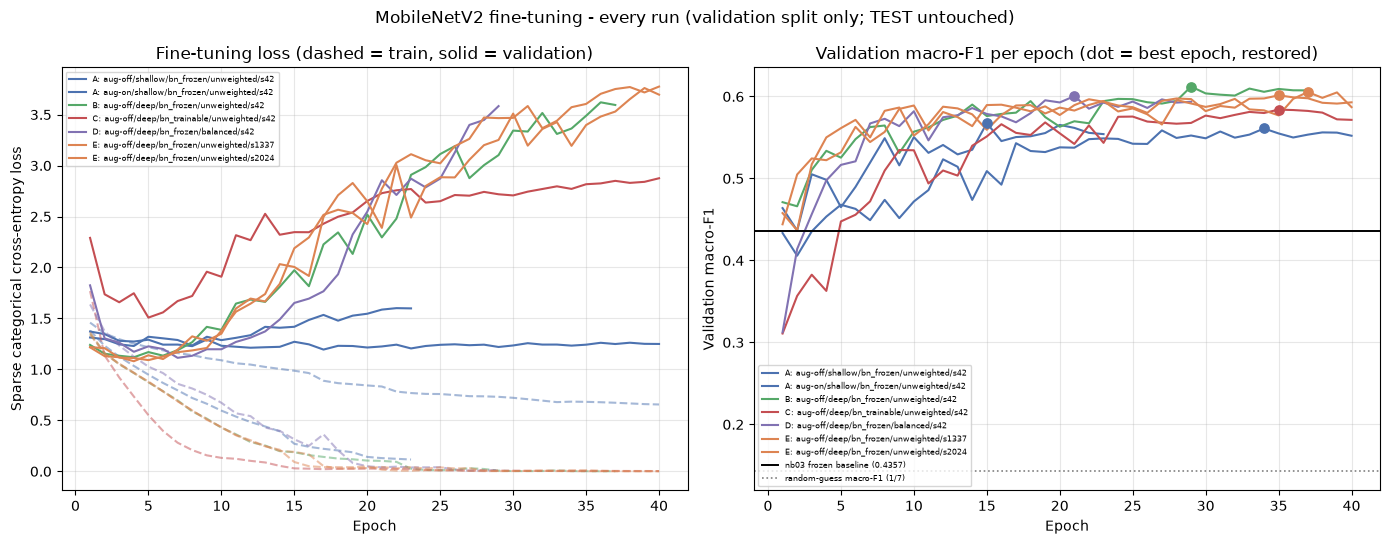

saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/plots/nb04_training_curves.png


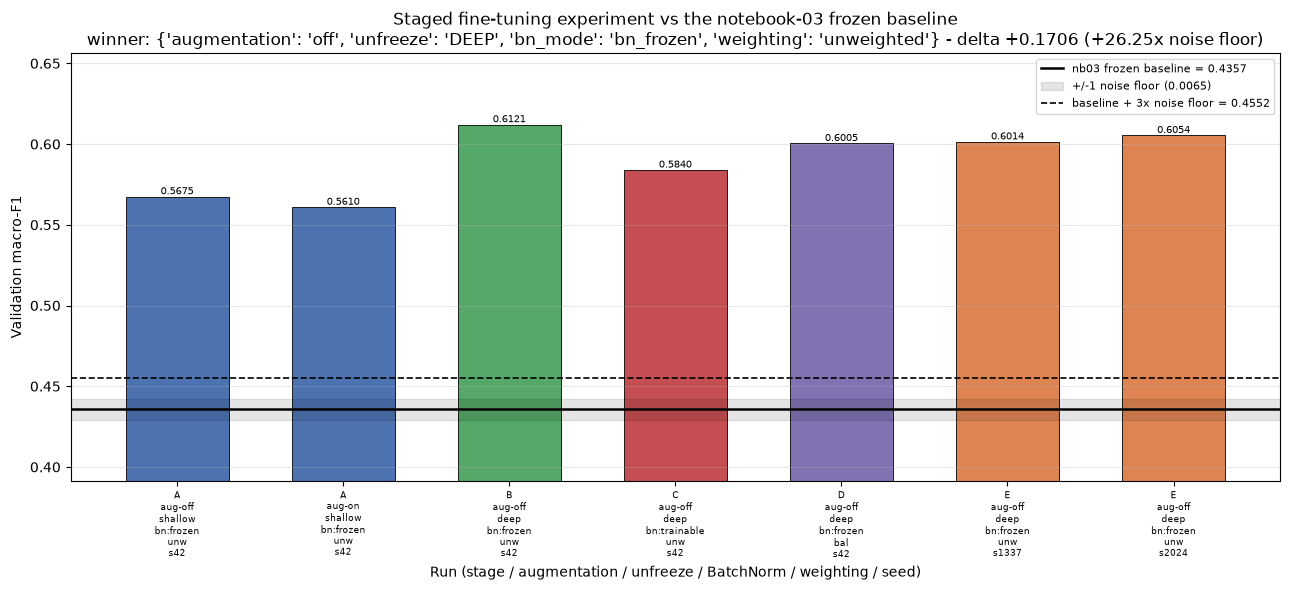

saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/plots/nb04_stage_comparison.png


In [21]:
import matplotlib
import matplotlib.pyplot as plt

_cycle = matplotlib.rcParams["axes.prop_cycle"].by_key()["color"]
_STAGE_COLORS = {"A": "#4C72B0", "B": "#55A868", "C": "#C44E52", "D": "#8172B2", "E": "#DD8452"}

def stage_color(r, i):
    return _STAGE_COLORS.get(r["stage"], _cycle[i % len(_cycle)])

# --- (1) training curves -----------------------------------------------------
p1 = os.path.join(PLOT_DIR, "nb04_training_curves.png")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for i, r in enumerate(ALL_RUNS):
    col = stage_color(r, i)
    ep = np.arange(1, len(r["history"]["loss"]) + 1)
    _lbl = f"{r['stage']}: aug-{r['augmentation']}/{r['unfreeze'].lower()}/{r['bn_mode']}/{r['weighting']}/s{r['seed']}"
    axes[0].plot(ep, r["history"]["loss"], color=col, linestyle="--", alpha=0.5)
    axes[0].plot(ep, r["history"]["val_loss"], color=col, linestyle="-", label=_lbl)
    axes[1].plot(ep, r["history"]["val_macro_f1"], color=col, linestyle="-", label=_lbl)
    axes[1].scatter([r["best_epoch"]], [r["history"]["val_macro_f1"][r["best_epoch"] - 1]],
                    color=col, marker="o", s=45, zorder=5)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy loss")
axes[0].set_title("Fine-tuning loss (dashed = train, solid = validation)")
axes[0].legend(fontsize=6)
axes[0].grid(alpha=0.3)

axes[1].axhline(BASELINE_MACRO_F1_MEAN, color="black", linestyle="-", linewidth=1.4,
                label=f"nb03 frozen baseline ({BASELINE_MACRO_F1_MEAN:.4f})")
axes[1].axhline(1.0 / N_CLASSES, color="grey", linestyle=":", linewidth=1.2,
                label=f"random-guess macro-F1 (1/{N_CLASSES})")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation macro-F1")
axes[1].set_title("Validation macro-F1 per epoch (dot = best epoch, restored)")
axes[1].legend(fontsize=6)
axes[1].grid(alpha=0.3)

fig.suptitle("MobileNetV2 fine-tuning - every run (validation split only; TEST untouched)")
plt.tight_layout()
plt.savefig(p1, dpi=150, bbox_inches="tight")
track_write(p1)
plt.show()
print("saved:", p1)

# --- (2) stage comparison, with the baseline reference line ------------------
p2 = os.path.join(PLOT_DIR, "nb04_stage_comparison.png")
fig, ax = plt.subplots(figsize=(13, 6))
_x = np.arange(len(stage_df))
_cols = [stage_color(r, i) for i, r in enumerate(ALL_RUNS)]
ax.bar(_x, stage_df["val_macro_f1"], 0.62, color=_cols, edgecolor="black", linewidth=0.6)
for xi, v in enumerate(stage_df["val_macro_f1"]):
    ax.text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=7)

# the notebook-03 frozen baseline and its noise band
ax.axhline(BASELINE_MACRO_F1_MEAN, color="black", linestyle="-", linewidth=1.8,
           label=f"nb03 frozen baseline = {BASELINE_MACRO_F1_MEAN:.4f}")
ax.axhspan(BASELINE_MACRO_F1_MEAN - NOISE_FLOOR_MACRO_F1,
           BASELINE_MACRO_F1_MEAN + NOISE_FLOOR_MACRO_F1,
           color="black", alpha=0.10,
           label=f"+/-1 noise floor ({NOISE_FLOOR_MACRO_F1:.4f})")
ax.axhline(BASELINE_MACRO_F1_MEAN + 3 * NOISE_FLOOR_MACRO_F1, color="black",
           linestyle="--", linewidth=1.2,
           label=f"baseline + 3x noise floor = "
                 f"{BASELINE_MACRO_F1_MEAN + 3 * NOISE_FLOOR_MACRO_F1:.4f}")

_labels = [f"{r['stage']}\naug-{r['augmentation']}\n{r['unfreeze'].lower()}\n"
           f"{r['bn_mode'].replace('bn_', 'bn:')}\n{r['weighting'][:3]}\ns{r['seed']}"
           for r in ALL_RUNS]
ax.set_xticks(_x)
ax.set_xticklabels(_labels, fontsize=6.5)
ax.set_xlabel("Run (stage / augmentation / unfreeze / BatchNorm / weighting / seed)")
ax.set_ylabel("Validation macro-F1")
ax.set_title(f"Staged fine-tuning experiment vs the notebook-03 frozen baseline\n"
             f"winner: {WINNING_CONFIG} - delta {DELTA_MACRO_F1:+.4f} "
             f"({DELTA_IN_NOISE_UNITS:+.2f}x noise floor)")
_lo = min(float(stage_df["val_macro_f1"].min()), BASELINE_MACRO_F1_MEAN)
_hi = max(float(stage_df["val_macro_f1"].max()),
          BASELINE_MACRO_F1_MEAN + 3 * NOISE_FLOOR_MACRO_F1)
_pad = max(0.02, (_hi - _lo) * 0.25)
ax.set_ylim(max(0.0, _lo - _pad), _hi + _pad)
ax.legend(fontsize=8, loc="best")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(p2, dpi=150, bbox_inches="tight")
track_write(p2)
plt.show()
print("saved:", p2)


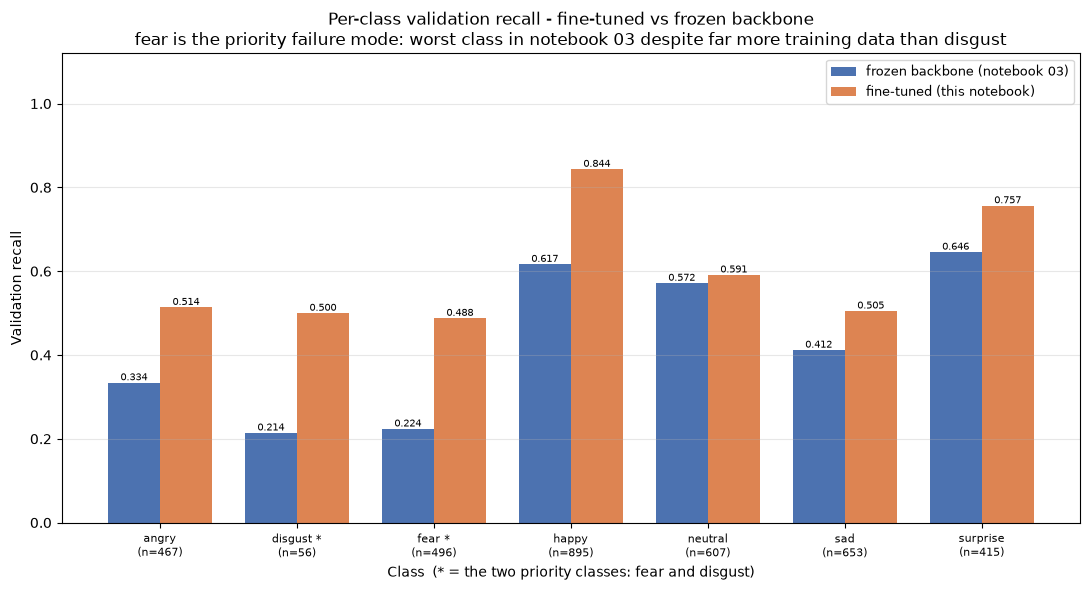

saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/plots/nb04_per_class_recall.png


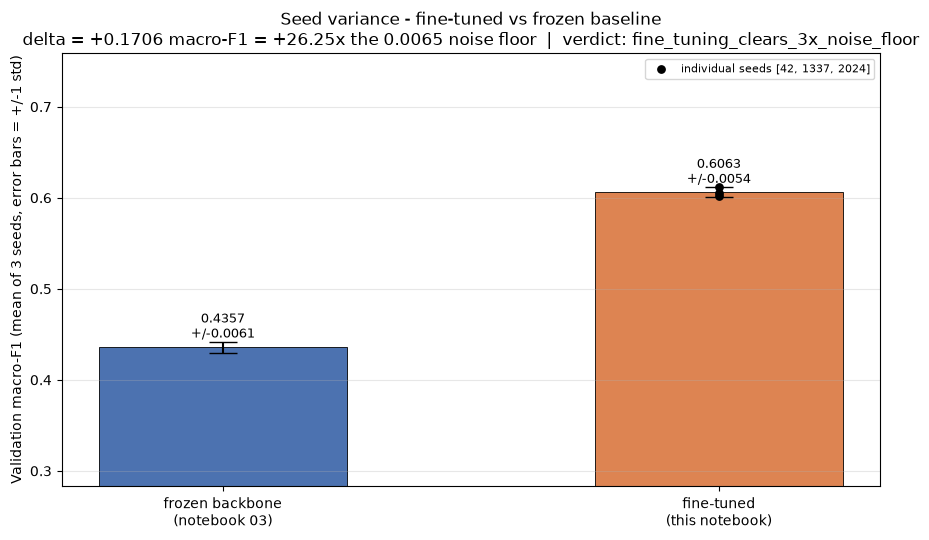

saved: /mnt/c/Users/Yasindu/Desktop/Chat_Research/IT22638168/ml/fer/plots/nb04_seed_variance.png

All four figures are curves and bar charts. No figure in this notebook contains a face.


In [22]:
# --- (3) per-class recall: winner vs frozen baseline -------------------------
p3 = os.path.join(PLOT_DIR, "nb04_per_class_recall.png")
fig, ax = plt.subplots(figsize=(11, 6))
_x = np.arange(N_CLASSES)
_ft_recall = [FINAL_REPORT[c]["recall"] for c in CLASS_NAMES]

if BASELINE_PER_CLASS is not None:
    _bl_recall = [BASELINE_PER_CLASS.get(c, {}).get("recall", np.nan) for c in CLASS_NAMES]
    _w = 0.38
    ax.bar(_x - _w / 2, _bl_recall, _w, label="frozen backbone (notebook 03)", color="#4C72B0")
    ax.bar(_x + _w / 2, _ft_recall, _w, label="fine-tuned (this notebook)", color="#DD8452")
    for xi, (b, f) in enumerate(zip(_bl_recall, _ft_recall)):
        if np.isfinite(b):
            ax.text(xi - _w / 2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=7)
        ax.text(xi + _w / 2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=7)
    _title_extra = ""
else:
    ax.bar(_x, _ft_recall, 0.6, label="fine-tuned (this notebook)", color="#DD8452")
    for xi, f in enumerate(_ft_recall):
        ax.text(xi, f, f"{f:.3f}", ha="center", va="bottom", fontsize=7)
    _title_extra = "\n(nb03_per_class_metrics.csv not found - baseline bars omitted)"

_ticklabels = []
for c in CLASS_NAMES:
    _sup = int(FINAL_REPORT[c]["support"])
    _mark = " *" if c in ("fear", "disgust") else ""
    _ticklabels.append(f"{c}{_mark}\n(n={_sup})")
ax.set_xticks(_x)
ax.set_xticklabels(_ticklabels, fontsize=8)
ax.set_xlabel("Class  (* = the two priority classes: fear and disgust)")
ax.set_ylabel("Validation recall")
ax.set_title("Per-class validation recall - fine-tuned vs frozen backbone" + _title_extra +
             "\nfear is the priority failure mode: worst class in notebook 03 despite far more "
             "training data than disgust")
ax.set_ylim(0, 1.12)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(p3, dpi=150, bbox_inches="tight")
track_write(p3)
plt.show()
print("saved:", p3)

# --- (4) seed variance: winner vs baseline, mean +/- 1 std -------------------
p4 = os.path.join(PLOT_DIR, "nb04_seed_variance.png")
fig, ax = plt.subplots(figsize=(9, 5.5))
_names = ["frozen backbone\n(notebook 03)", "fine-tuned\n(this notebook)"]
_means = [BASELINE_MACRO_F1_MEAN, WINNER_MACRO_F1_MEAN]
_stds = [BASELINE_MACRO_F1_STD, WINNER_MACRO_F1_STD]
_bar_x = np.arange(2)
ax.bar(_bar_x, _means, 0.5, yerr=_stds, capsize=10,
       color=["#4C72B0", "#DD8452"], edgecolor="black", linewidth=0.6,
       error_kw={"ecolor": "black", "elinewidth": 1.5})
for xi, (m, s) in enumerate(zip(_means, _stds)):
    ax.text(xi, m + s, f"{m:.4f}\n+/-{s:.4f}", ha="center", va="bottom", fontsize=9)

# the individual seeds of the fine-tuned model, so the spread is not just an error bar
_seed_vals = [r["val_macro_f1"] for r in winner_runs]
ax.scatter([1] * len(_seed_vals), _seed_vals, color="black", zorder=6, s=28,
           label=f"individual seeds {SEEDS}")

ax.set_xticks(_bar_x)
ax.set_xticklabels(_names)
ax.set_ylabel("Validation macro-F1 (mean of 3 seeds, error bars = +/-1 std)")
ax.set_title(f"Seed variance - fine-tuned vs frozen baseline\n"
             f"delta = {DELTA_MACRO_F1:+.4f} macro-F1 = {DELTA_IN_NOISE_UNITS:+.2f}x the "
             f"{NOISE_FLOOR_MACRO_F1:.4f} noise floor  |  verdict: {VERDICT}")
_lo = min(min(_means) - max(_stds), min(_seed_vals))
_hi = max(max(_means) + max(_stds), max(_seed_vals))
_pad = max(0.02, (_hi - _lo) * 0.8)
ax.set_ylim(max(0.0, _lo - _pad), _hi + _pad)
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(p4, dpi=150, bbox_inches="tight")
track_write(p4)
plt.show()
print("saved:", p4)
print()
print("All four figures are curves and bar charts. No figure in this notebook contains a face.")


## 8. Sanity gates

Five checks, each printing PASS or FAIL explicitly. Nothing here passes silently, and a failure is
banner-printed rather than swallowed, so a broken run cannot be mistaken for a good one at a glance.

1. **Validation accuracy beats the majority-class rate**, computed at runtime from `y_val`. A
   classifier that always answered with the largest class would score that, so failing this means
   the model learned nothing useful.
2. **Validation macro-F1 beats 1/7** — the floor for uninformative predictions over 7 classes.
3. **No TEST/PrivateTest row entered any array** — re-asserted from scratch over every path list,
   the manifest, the in-RAM arrays' provenance, and the exported probability CSV.
4. **The GPU was actually used** — the device is reported, and a CPU-only run is banner-warned.
   (§1 raises before reaching here if no GPU is visible at all, so this gate documents *which*
   device did the work.)
5. **`disgust` AND `fear` recall reported for every run.** `fear` is the priority failure mode:
   notebook 03 measured it as the worst class *despite* having far more training data than
   `disgust`, so it is not a data-quantity problem and augmentation or weighting alone should not
   be expected to fix it.

In [23]:
print("=" * 78)
print("SANITY GATES")
print("=" * 78)
gates = {}

# --- gate 1: val accuracy > majority-class rate ------------------------------
_counts = np.bincount(y_val, minlength=N_CLASSES)
majority_idx = int(np.argmax(_counts))
majority_rate = float(_counts[majority_idx]) / float(len(y_val))
g1 = FINAL_VAL_ACC > majority_rate
gates["val_accuracy_beats_majority_class"] = g1
print(f"[{'PASS' if g1 else 'FAIL'}] gate 1: val accuracy > majority-class rate")
print(f"         majority class = '{CLASS_NAMES[majority_idx]}' "
      f"({int(_counts[majority_idx])}/{len(y_val)} = {majority_rate:.4f})")
print(f"         val accuracy   = {FINAL_VAL_ACC:.4f}   "
      f"margin = {FINAL_VAL_ACC - majority_rate:+.4f}")

# --- gate 2: val macro-F1 > 1/7 ----------------------------------------------
f1_floor = 1.0 / N_CLASSES
g2 = FINAL_VAL_MACRO_F1 > f1_floor
gates["val_macro_f1_beats_random"] = g2
print()
print(f"[{'PASS' if g2 else 'FAIL'}] gate 2: val macro-F1 > 1/{N_CLASSES}")
print(f"         floor        = {f1_floor:.4f}")
print(f"         val macro-F1 = {FINAL_VAL_MACRO_F1:.4f}   "
      f"margin = {FINAL_VAL_MACRO_F1 - f1_floor:+.4f}")

# --- gate 3: no TEST/PrivateTest anywhere ------------------------------------
print()
try:
    assert_no_test(train_paths, val_paths, label="gate 3 path arrays")
    assert "TEST" not in set(manifest["split_group"]), "TEST rows present in manifest"
    assert not manifest["basename"].str.startswith("PrivateTest_").any(), \
        "PrivateTest_ basename present in manifest"
    assert not any(str(b).startswith("PrivateTest_") for b in val_basenames), \
        "PrivateTest_ basename present in val_basenames"
    assert not any(str(b).startswith("PrivateTest_") for b in train_basenames), \
        "PrivateTest_ basename present in train_basenames"
    assert not prob_df["basename"].str.startswith("PrivateTest_").any(), \
        "PrivateTest_ basename present in the exported probabilities"
    assert len(train_paths) + len(val_paths) == len(manifest), \
        "path arrays and manifest disagree on row count"
    assert X_train_u8.shape[0] == len(train_paths) and X_val_u8.shape[0] == len(val_paths), \
        "in-RAM pixel arrays do not match the TEST-free path arrays"
    g3 = True
except AssertionError as e:
    g3 = False
    print("         ", e)
gates["no_test_split_used"] = g3
print(f"[{'PASS' if g3 else 'FAIL'}] gate 3: no TEST/PrivateTest row entered any array")
print(f"         manifest split_groups present: {sorted(set(manifest['split_group']))}")
print(f"         train={len(train_paths)}  val={len(val_paths)}  manifest={len(manifest)}  "
      f"pixels={X_train_u8.shape[0]}+{X_val_u8.shape[0]}")

# --- gate 4: the GPU was actually used ---------------------------------------
print()
_gpu_devices = tf.config.list_physical_devices("GPU")
g4 = bool(_gpu_devices) and bool(GPU_AVAILABLE)
gates["gpu_used"] = g4
print(f"[{'PASS' if g4 else 'FAIL'}] gate 4: training ran on a GPU")
print(f"         device      : {GPU_DEVICE_NAME}")
print(f"         description : {GPU_DEVICE_DESCRIPTION}")
print(f"         mixed precision: {tf.keras.mixed_precision.global_policy().name}")
print(f"         {len(ALL_RUNS)} runs, {CUMULATIVE_TRAIN_SECONDS / 60:.1f} min of training")
if not g4:
    print("!" * 78)
    print("!!  NO GPU - these timings and possibly these results came from a CPU run.   !!")
    print("!!  Fine-tuning on CPU is hours per epoch; treat every number here as        !!")
    print("!!  suspect until the notebook is re-run on the WSL2 GPU kernel.             !!")
    print("!" * 78)

# --- gate 5: disgust AND fear recall reported for EVERY run ------------------
print()
print("[INFO] gate 5: disgust and fear recall for every run")
print(f"         {'run':<52} {'disgust':>8} {'fear':>8}")
_reported = []
for r in ALL_RUNS:
    _d = r["per_class"]["disgust"]["recall"]
    _f = r["per_class"]["fear"]["recall"]
    _reported.append((_d, _f))
    print(f"         {r['tag']:<52} {_d:>8.4f} {_f:>8.4f}")
g5 = (len(_reported) == len(ALL_RUNS)
      and all(np.isfinite(d) and np.isfinite(f) for d, f in _reported))
gates["disgust_and_fear_recall_reported_for_all_runs"] = g5
print(f"[{'PASS' if g5 else 'FAIL'}] gate 5: both recalls present for all {len(ALL_RUNS)} runs")
_worst_class = min(CLASS_NAMES, key=lambda c: FINAL_REPORT[c]["recall"])
print(f"         winner: disgust recall = {FINAL_REPORT['disgust']['recall']:.4f}, "
      f"fear recall = {FINAL_REPORT['fear']['recall']:.4f}")
print(f"         winner's worst class by recall: '{_worst_class}' "
      f"({FINAL_REPORT[_worst_class]['recall']:.4f})")
if _worst_class == "fear":
    print("         >> fear is still the worst class after fine-tuning - notebook 03's "
          "finding holds.")
else:
    print(f"         >> the worst class is now '{_worst_class}', not fear - notebook 03's "
          "finding did NOT survive fine-tuning; report the change.")

# --- summary ------------------------------------------------------------------
ALL_GATES_OK = all(gates.values())
print()
print("=" * 78)
if ALL_GATES_OK:
    print("ALL SANITY GATES PASSED.")
else:
    print("!" * 78)
    print("!!  ONE OR MORE SANITY GATES FAILED - do NOT proceed to notebook 05         !!")
    print("!!  until the failure below is understood.                                  !!")
    for k, v in gates.items():
        if not v:
            print(f"!!    FAILED: {k}")
    print("!" * 78)
print("=" * 78)

RUN["metrics"]["sanity_gates"] = {k: bool(v) for k, v in gates.items()}
RUN["metrics"]["majority_class_rate_val"] = majority_rate
RUN["metrics"]["macro_f1_floor"] = f1_floor
RUN["metrics"]["worst_class_by_recall"] = _worst_class
run_path = save_run(RUN)   # rewrite with the gate results included


SANITY GATES
[PASS] gate 1: val accuracy > majority-class rate
         majority class = 'happy' (895/3589 = 0.2494)
         val accuracy   = 0.6319   margin = +0.3826

[PASS] gate 2: val macro-F1 > 1/7
         floor        = 0.1429
         val macro-F1 = 0.6121   margin = +0.4692

[PASS] gate 3: no TEST/PrivateTest row entered any array
         manifest split_groups present: ['TRAIN', 'VAL']
         train=26901  val=3589  manifest=30490  pixels=26901+3589

[PASS] gate 4: training ran on a GPU
         device      : /physical_device:GPU:0
         description : NVIDIA GeForce RTX 3050 6GB Laptop GPU
         mixed precision: float32
         7 runs, 57.6 min of training

[INFO] gate 5: disgust and fear recall for every run
         run                                                   disgust     fear
         A_aug-off_shallow_bn_frozen_unweighted_s42             0.5000   0.4052
         A_aug-on_shallow_bn_frozen_unweighted_s42              0.3750   0.3871
         B_aug-off_dee

## 9. Byte report

Every file this notebook wrote, and the total. One bucket: unlike notebook 03, nothing here is a
regenerable disk cache — the in-RAM image array never touches disk — so everything listed is
committed evidence in `outputs/`, `plots/` and `models/`. Disk headroom on the Windows volume is
roughly 3.4 GB, and the model is the only file of any size.

In [24]:
print("=" * 78)
print("ARTIFACT BYTES (OUT_DIR / PLOT_DIR / MODELS_DIR - written straight into the repo)")
print("=" * 78)
artifact_df = pd.DataFrame(_WRITTEN_FILES, columns=["path", "bytes"])
artifact_df["file"] = [os.path.relpath(p, REPO_ROOT) for p in artifact_df["path"]]
print(artifact_df[["file", "bytes"]].to_string(index=False))

artifact_total = bucket_bytes(_WRITTEN_FILES)
print()
print("=" * 78)
print(f"TOTAL BYTES WRITTEN BY NOTEBOOK 04: {artifact_total} "
      f"({artifact_total / 1e6:.2f} MB)")
print("=" * 78)
print("No regenerable cache was written: the decoded images lived in RAM only.")
print()
print(f"Decode wall time      : {DECODE_SECONDS_TOTAL:.1f}s (once, not per epoch)")
print(f"Total training time   : {CUMULATIVE_TRAIN_SECONDS / 60:.1f} min "
      f"over {len(ALL_RUNS)} runs")
print(f"Model saved           : {RUN['model_version']}")
print(f"Run record            : {RUN['run_id']}.json")


ARTIFACT BYTES (OUT_DIR / PLOT_DIR / MODELS_DIR - written straight into the repo)
                                            file    bytes
           ml/fer/outputs/nb04_stage_results.csv     4751
           ml/fer/outputs/nb04_seed_variance.csv     1305
       ml/fer/outputs/nb04_val_probabilities.csv   466335
       ml/fer/outputs/nb04_per_class_metrics.csv      964
ml/fer/models/fer_mobilenetv2_finetuned_96.keras 24464001
         ml/fer/outputs/run_20260823_163030.json    12724
           ml/fer/plots/nb04_training_curves.png   356180
          ml/fer/plots/nb04_stage_comparison.png   115991
          ml/fer/plots/nb04_per_class_recall.png    84592
             ml/fer/plots/nb04_seed_variance.png    70808

TOTAL BYTES WRITTEN BY NOTEBOOK 04: 25577651 (25.58 MB)
No regenerable cache was written: the decoded images lived in RAM only.

Decode wall time      : 3.5s (once, not per epoch)
Total training time   : 57.6 min over 7 runs
Model saved           : fer_mobilenetv2_finetuned_96.k